# 0. Boilerplate Setup

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import json
import hashlib
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix, hstack
from time import perf_counter
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold


In [5]:
def find_competition_data_dir(input_root):
    """Find the unique Kaggle input directory containing train.tsv and test.tsv."""
    input_root = Path(input_root)

    if not input_root.exists():
        raise FileNotFoundError(f"Kaggle input directory not found: {input_root}")

    candidates = sorted({
        path.parent
        for path in input_root.rglob("train.tsv")
        if (path.parent / "test.tsv").exists()
    })

    if not candidates:
        raise FileNotFoundError(
            "Could not find a directory under /kaggle/input containing both "
            "train.tsv and test.tsv."
        )

    if len(candidates) > 1:
        sample_submission_candidates = [
            path
            for path in candidates
            if any(path.glob("*sample*"))
        ]

        if len(sample_submission_candidates) == 1:
            candidates = sample_submission_candidates

    if len(candidates) != 1:
        raise RuntimeError(
            "Multiple candidate competition-data directories were found:\n"
            + "\n".join(str(path) for path in candidates)
            + "\nRemove the ambiguity before running the notebook."
        )

    return candidates[0]


KAGGLE_INPUT_ROOT = Path(
    os.environ.get("KAGGLE_INPUT_DIR", "/kaggle/input")
)

KAGGLE_WORKING_ROOT = Path(
    os.environ.get("KAGGLE_WORKING_DIR", "/kaggle/working")
)

DATA_DIR = find_competition_data_dir(KAGGLE_INPUT_ROOT)

train_path = DATA_DIR / "train.tsv"
test_path = DATA_DIR / "test.tsv"

train = pd.read_csv(
    train_path,
    sep="\t",
    dtype={
        "train_id": "int32",
        "item_condition_id": "int8",
        "shipping": "int8"
    }
)

test = pd.read_csv(
    test_path,
    sep="\t",
    dtype={
        "test_id": "int32",
        "item_condition_id": "int8",
        "shipping": "int8"
    }
)


def dataframe_column_hash(series):
    values = pd.util.hash_pandas_object(
        series,
        index=True
    ).to_numpy(dtype=np.uint64)

    return hashlib.sha256(values.tobytes()).hexdigest()


DATA_FINGERPRINT = hashlib.sha256(
    json.dumps(
        {
            "train_rows": int(len(train)),
            "test_rows": int(len(test)),
            "train_columns": list(train.columns),
            "test_columns": list(test.columns),
            "train_id_hash": dataframe_column_hash(train["train_id"]),
            "test_id_hash": dataframe_column_hash(test["test_id"]),
            "price_hash": dataframe_column_hash(train["price"])
        },
        sort_keys=True
    ).encode("utf-8")
).hexdigest()

print("DATA DIRECTORY:", DATA_DIR)
print("TRAIN SHAPE:", train.shape)
print("TEST SHAPE:", test.shape)
print("DATA FINGERPRINT:", DATA_FINGERPRINT)


DATA DIRECTORY: /kaggle/input/datasets/saitosean/mercari
TRAIN SHAPE: (1482535, 8)
TEST SHAPE: (693359, 7)
DATA FINGERPRINT: 1477d6031f1c07aae69cb530d5cf614622c7f0ecd02eae329b79eb44b8f932f0


## 0.1 Restart-Safe Persistence & Recovery

This notebook treats Python RAM as temporary state. Expensive or important artifacts are saved under `/kaggle/working/mercari_cache` and loaded automatically when a compatible artifact already exists.

When a previous notebook version/output is attached under `/kaggle/input`, the loader discovers the cache by its manifest instead of relying on a hard-coded input path.

Cache compatibility is checked using:
- project/cache schema version
- dataset fingerprint
- split configuration
- feature/model configuration

A stale or incompatible artifact is ignored and rebuilt rather than silently reused.


In [6]:
CACHE_SCHEMA_VERSION = 1
PROJECT_NAME = "mercari"

LOCAL_CACHE_ROOT = (
    KAGGLE_WORKING_ROOT
    / f"{PROJECT_NAME}_cache"
)
LOCAL_CACHE_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

CACHE_MANIFEST_NAME = "cache_manifest.json"


def _find_attached_cache_roots(input_root):
    """Locate caches from earlier saved notebook outputs attached as inputs."""
    input_root = Path(input_root)

    if not input_root.exists():
        return []

    roots = []

    for manifest_path in input_root.rglob(CACHE_MANIFEST_NAME):
        try:
            with open(manifest_path, "r", encoding="utf-8") as handle:
                manifest = json.load(handle)

            if (
                manifest.get("project") == PROJECT_NAME
                and manifest.get("cache_schema_version") == CACHE_SCHEMA_VERSION
            ):
                roots.append(manifest_path.parent)

        except (OSError, json.JSONDecodeError):
            continue

    unique_roots = []
    seen = set()

    for root in sorted(roots):
        root = root.resolve()

        if root not in seen:
            unique_roots.append(root)
            seen.add(root)

    return unique_roots


ATTACHED_CACHE_ROOTS = _find_attached_cache_roots(
    KAGGLE_INPUT_ROOT
)

ARTIFACT_SEARCH_ROOTS = [
    LOCAL_CACHE_ROOT,
    *[
        root
        for root in ATTACHED_CACHE_ROOTS
        if root != LOCAL_CACHE_ROOT
    ]
]

LOCAL_CACHE_MANIFEST = {
    "project": PROJECT_NAME,
    "cache_schema_version": CACHE_SCHEMA_VERSION
}

with open(
    LOCAL_CACHE_ROOT / CACHE_MANIFEST_NAME,
    "w",
    encoding="utf-8"
) as handle:
    json.dump(
        LOCAL_CACHE_MANIFEST,
        handle,
        indent=2
    )


def _stable_hash(config):
    serialized = json.dumps(
        config,
        sort_keys=True,
        separators=(",", ":"),
        default=str
    ).encode("utf-8")

    return hashlib.sha256(serialized).hexdigest()


def _artifact_data_path(root, name, suffix):
    return Path(root) / f"{name}{suffix}"


def _artifact_meta_path(root, name):
    return Path(root) / f"{name}.meta.json"


def _find_artifact(name, suffix):
    for root in ARTIFACT_SEARCH_ROOTS:
        data_path = _artifact_data_path(
            root,
            name,
            suffix
        )

        meta_path = _artifact_meta_path(
            root,
            name
        )

        if data_path.exists() and meta_path.exists():
            return data_path, meta_path

    return None


def _load_meta(meta_path):
    try:
        with open(
            meta_path,
            "r",
            encoding="utf-8"
        ) as handle:
            return json.load(handle)

    except (OSError, json.JSONDecodeError):
        return None


def _cache_is_compatible(meta, expected_config):
    if meta is None:
        return False

    if meta.get("project") != PROJECT_NAME:
        return False

    if meta.get("cache_schema_version") != CACHE_SCHEMA_VERSION:
        return False

    return (
        meta.get("config_hash")
        == _stable_hash(expected_config)
    )


def _save_meta(name, config):
    meta = {
        "project": PROJECT_NAME,
        "cache_schema_version": CACHE_SCHEMA_VERSION,
        "config_hash": _stable_hash(config),
        "config": config
    }

    with open(
        _artifact_meta_path(
            LOCAL_CACHE_ROOT,
            name
        ),
        "w",
        encoding="utf-8"
    ) as handle:
        json.dump(
            meta,
            handle,
            indent=2,
            default=str
        )


def save_json_artifact(name, payload, config):
    path = _artifact_data_path(
        LOCAL_CACHE_ROOT,
        name,
        ".json"
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as handle:
        json.dump(
            payload,
            handle,
            indent=2,
            default=str
        )

    _save_meta(
        name,
        config
    )


def load_json_artifact(name, config):
    found = _find_artifact(
        name,
        ".json"
    )

    if found is None:
        return None

    data_path, meta_path = found
    meta = _load_meta(meta_path)

    if not _cache_is_compatible(
        meta,
        config
    ):
        print(
            f"IGNORING INCOMPATIBLE CACHE: {name}"
        )
        return None

    with open(
        data_path,
        "r",
        encoding="utf-8"
    ) as handle:
        return json.load(handle)


def save_numpy_artifact(name, array, config):
    path = _artifact_data_path(
        LOCAL_CACHE_ROOT,
        name,
        ".npy"
    )

    np.save(
        path,
        array
    )

    _save_meta(
        name,
        config
    )


def load_numpy_artifact(name, config):
    found = _find_artifact(
        name,
        ".npy"
    )

    if found is None:
        return None

    data_path, meta_path = found
    meta = _load_meta(meta_path)

    if not _cache_is_compatible(
        meta,
        config
    ):
        print(
            f"IGNORING INCOMPATIBLE CACHE: {name}"
        )
        return None

    return np.load(
        data_path,
        allow_pickle=False
    )


def save_joblib_artifact(name, obj, config):
    path = _artifact_data_path(
        LOCAL_CACHE_ROOT,
        name,
        ".joblib"
    )

    joblib.dump(
        obj,
        path,
        compress=3
    )

    _save_meta(
        name,
        config
    )


def load_joblib_artifact(name, config):
    found = _find_artifact(
        name,
        ".joblib"
    )

    if found is None:
        return None

    data_path, meta_path = found
    meta = _load_meta(meta_path)

    if not _cache_is_compatible(
        meta,
        config
    ):
        print(
            f"IGNORING INCOMPATIBLE CACHE: {name}"
        )
        return None

    return joblib.load(
        data_path
    )


def save_dataframe_json_artifact(name, dataframe, config):
    payload = json.loads(
        dataframe.to_json(
            orient="records"
        )
    )

    save_json_artifact(
        name,
        payload,
        config
    )


def load_dataframe_json_artifact(name, config):
    payload = load_json_artifact(
        name,
        config
    )

    if payload is None:
        return None

    return pd.DataFrame(payload)


def save_catboost_artifact(name, model, config):
    path = _artifact_data_path(
        LOCAL_CACHE_ROOT,
        name,
        ".cbm"
    )

    model.save_model(
        str(path)
    )

    _save_meta(
        name,
        config
    )


def load_catboost_artifact(name, config):
    found = _find_artifact(
        name,
        ".cbm"
    )

    if found is None:
        return None

    data_path, meta_path = found
    meta = _load_meta(meta_path)

    if not _cache_is_compatible(
        meta,
        config
    ):
        print(
            f"IGNORING INCOMPATIBLE CACHE: {name}"
        )
        return None

    model = CatBoostRegressor()
    model.load_model(
        str(data_path)
    )

    return model


def cache_status():
    tracked_artifacts = [
        ("split_train_idx", ".npy"),
        ("split_val_idx", ".npy"),
        ("name_tfidf_vectorizer", ".joblib"),
        ("description_tfidf_vectorizer", ".joblib"),
        ("tfidf_ridge_model", ".joblib"),
        ("combined_ohe_encoder", ".joblib"),
        ("combined_numeric_scaler", ".joblib"),
        ("combined_ridge_model", ".joblib"),
        ("catboost_structured_model", ".cbm"),
        ("ablation_results", ".json"),
        ("target_encoding_result", ".json"),
        ("experiment_registry", ".json")
    ]

    rows = []

    for name, suffix in tracked_artifacts:
        found = _find_artifact(
            name,
            suffix
        )

        rows.append({
            "artifact": name,
            "available": found is not None,
            "source": (
                str(found[0])
                if found is not None
                else None
            )
        })

    return pd.DataFrame(rows)


print("LOCAL CACHE:", LOCAL_CACHE_ROOT)

if ATTACHED_CACHE_ROOTS:
    print("\nATTACHED CACHES FOUND:")
    for root in ATTACHED_CACHE_ROOTS:
        print(root)
else:
    print("\nNO ATTACHED PRIOR CACHE FOUND.")

print("\nCACHE STATUS")
print(
    cache_status().to_string(index=False)
)

# Explicit experiment configuration objects.
# These are derived configuration values, not notebook-session state.
SPLIT_CONFIG = {
    "test_size": 0.20,
    "random_state": 42,
    "shuffle": True,
    "n_rows": int(len(train)),
    "data_fingerprint": DATA_FINGERPRINT
}

TFIDF_CONFIG = {
    "ngram_range": [1, 2],
    "max_features": 5000,
    "min_df": 2,
    "max_df": 0.95,
    "dtype": "float32",
    "data_fingerprint": DATA_FINGERPRINT,
    "split_config": SPLIT_CONFIG
}



LOCAL CACHE: /kaggle/working/mercari_cache

NO ATTACHED PRIOR CACHE FOUND.

CACHE STATUS
                    artifact  available source
             split_train_idx      False   None
               split_val_idx      False   None
       name_tfidf_vectorizer      False   None
description_tfidf_vectorizer      False   None
           tfidf_ridge_model      False   None
        combined_ohe_encoder      False   None
     combined_numeric_scaler      False   None
        combined_ridge_model      False   None
   catboost_structured_model      False   None
            ablation_results      False   None
      target_encoding_result      False   None
         experiment_registry      False   None


### Recovery rule for future sessions

After the first successful run with this version of the notebook, **save a notebook version/output** so `/kaggle/working/mercari_cache` is persisted. On a fresh session, attach that saved output if Kaggle does not already expose it under `/kaggle/input`.

Then:
1. Run the setup + data-ingestion cells.
2. The cache layer will automatically discover compatible prior artifacts.
3. Re-run only the cheap feature-construction cells needed for the next experiment.
4. Cached models/results will be loaded instead of retrained.

Large sparse TF-IDF matrices are intentionally **not** persisted; their fitted vectorizers are persisted and the matrices are rebuilt in memory. This avoids consuming most of the 1 GB artifact budget with redundant sparse copies.


# 1. Data Ingestion & Integrity 

**1.1. Schema & Column Structure**

- Verify expected columns exist.
- Verify train/test column differences are intentional.
- Verify column ordering if relevant.

In [7]:
expected_train_columns = {
    "train_id",
    "name",
    "item_condition_id",
    "category_name",
    "brand_name",
    "price",
    "shipping",
    "item_description"
}

expected_test_columns = {
    "test_id",
    "name",
    "item_condition_id",
    "category_name",
    "brand_name",
    "shipping",
    "item_description"
}

print("TRAIN MISSING:", sorted(expected_train_columns - set(train.columns)))
print("TRAIN UNEXPECTED:", sorted(set(train.columns) - expected_train_columns))

print("TEST MISSING:", sorted(expected_test_columns - set(test.columns)))
print("TEST UNEXPECTED:", sorted(set(test.columns) - expected_test_columns))

print("TRAIN COLUMN ORDER:", list(train.columns))
print("TEST COLUMN ORDER:", list(test.columns))

TRAIN MISSING: []
TRAIN UNEXPECTED: []
TEST MISSING: []
TEST UNEXPECTED: []
TRAIN COLUMN ORDER: ['train_id', 'name', 'item_condition_id', 'category_name', 'brand_name', 'price', 'shipping', 'item_description']
TEST COLUMN ORDER: ['test_id', 'name', 'item_condition_id', 'category_name', 'brand_name', 'shipping', 'item_description']


**1.2. Data Type Enforcement**

- Check actual dtypes against expected dtypes.
- Identify unexpected type coercion or inference.

In [8]:
expected_train_dtypes = {
    "train_id": "int32",
    "name": "object",
    "item_condition_id": "int8",
    "category_name": "object",
    "brand_name": "object",
    "price": "float64",
    "shipping": "int8",
    "item_description": "object"
}

expected_test_dtypes = {
    "test_id": "int32",
    "name": "object",
    "item_condition_id": "int8",
    "category_name": "object",
    "brand_name": "object",
    "shipping": "int8",
    "item_description": "object"
}

train_dtype_check = pd.DataFrame({
    "actual": train.dtypes.astype(str),
    "expected": pd.Series(expected_train_dtypes)
})

train_dtype_check["match"] = (
    train_dtype_check["actual"] == train_dtype_check["expected"]
)

test_dtype_check = pd.DataFrame({
    "actual": test.dtypes.astype(str),
    "expected": pd.Series(expected_test_dtypes)
})

test_dtype_check["match"] = (
    test_dtype_check["actual"] == test_dtype_check["expected"]
)

print("TRAIN DTYPE CHECK")
print(train_dtype_check)

print("\nTEST DTYPE CHECK")
print(test_dtype_check)

TRAIN DTYPE CHECK
                    actual expected  match
train_id             int32    int32   True
name                object   object   True
item_condition_id     int8     int8   True
category_name       object   object   True
brand_name          object   object   True
price              float64  float64   True
shipping              int8     int8   True
item_description    object   object   True

TEST DTYPE CHECK
                   actual expected  match
test_id             int32    int32   True
name               object   object   True
item_condition_id    int8     int8   True
category_name      object   object   True
brand_name         object   object   True
shipping             int8     int8   True
item_description   object   object   True


**1.3. Null / Missing Value Audit**

- Count nulls per column.
- Identify unexpected nulls.

In [9]:
train_nulls = train.isna().sum()
test_nulls = test.isna().sum()

print("TRAIN NULLS")
print(train_nulls)

print("\nTEST NULLS")
print(test_nulls)

TRAIN NULLS
train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64

TEST NULLS
test_id                   0
name                      0
item_condition_id         0
category_name          3058
brand_name           295525
shipping                  0
item_description          0
dtype: int64


***Note:** train: brand_name: 632682 null values, category_name: 6362 null values, item_description: 6 null values.test: brand_name: 295525 null values, category_name: 3058 bull values.significantly high null values in brand_name, much less but existant null values in category_name.*

**1.4. Duplicate Row Audit**
- Check for completely duplicated rows in train and test.

In [10]:
train_duplicate_rows = train.duplicated().sum()
test_duplicate_rows = test.duplicated().sum()

print("TRAIN DUPLICATE ROWS:", train_duplicate_rows)
print("TEST DUPLICATE ROWS:", test_duplicate_rows)

TRAIN DUPLICATE ROWS: 0
TEST DUPLICATE ROWS: 0


**1.5. Primary Key Integrity**

- Check train_id uniqueness.
- Check test_id uniqueness.
- Check for null primary keys.

In [11]:
print("TRAIN PRIMARY KEY")
print("Nulls:", train["train_id"].isna().sum())
print("Unique:", train["train_id"].is_unique)
print("Duplicate IDs:", train["train_id"].duplicated().sum())

print("\nTEST PRIMARY KEY")
print("Nulls:", test["test_id"].isna().sum())
print("Unique:", test["test_id"].is_unique)
print("Duplicate IDs:", test["test_id"].duplicated().sum())

TRAIN PRIMARY KEY
Nulls: 0
Unique: True
Duplicate IDs: 0

TEST PRIMARY KEY
Nulls: 0
Unique: True
Duplicate IDs: 0


**1.6. Basic Value Validity**

- Check whether constrained fields such as item_condition_id and shipping contain valid values.

In [12]:
print("ITEM CONDITION ID - TRAIN")
print(sorted(train["item_condition_id"].unique()))

print("\nITEM CONDITION ID - TEST")
print(sorted(test["item_condition_id"].unique()))

print("\nSHIPPING - TRAIN")
print(sorted(train["shipping"].unique()))

print("\nSHIPPING - TEST")
print(sorted(test["shipping"].unique()))

ITEM CONDITION ID - TRAIN
[np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5)]

ITEM CONDITION ID - TEST
[np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5)]

SHIPPING - TRAIN
[np.int8(0), np.int8(1)]

SHIPPING - TEST
[np.int8(0), np.int8(1)]


**1.7. Train–Test Structural Consistency**

- Compare shared feature columns.
- Confirm price exists only in train.
- Check for schema mismatches between corresponding columns.

In [13]:
train_features = [col for col in train.columns if col not in ["train_id", "price"]]
test_features = [col for col in test.columns if col != "test_id"]

print("SHARED FEATURES:", train_features == test_features)
print("TRAIN FEATURES:", train_features)
print("TEST FEATURES:", test_features)

print("\nTRAIN-ONLY COLUMNS:", sorted(set(train.columns) - set(test.columns)))
print("TEST-ONLY COLUMNS:", sorted(set(test.columns) - set(train.columns)))

SHARED FEATURES: True
TRAIN FEATURES: ['name', 'item_condition_id', 'category_name', 'brand_name', 'shipping', 'item_description']
TEST FEATURES: ['name', 'item_condition_id', 'category_name', 'brand_name', 'shipping', 'item_description']

TRAIN-ONLY COLUMNS: ['price', 'train_id']
TEST-ONLY COLUMNS: ['test_id']


# 2. Data Understanding & Validation

**2.1. Target Distribution**
- Inspect price distribution.
- Measure central tendency, spread, minimum/maximum.
- Measure skewness and kurtosis.
- Inspect log1p(price) distribution because evaluation uses RMSLE.
- Check for zero/near-zero target values and extreme outliers.

TARGET SUMMARY
              price   log1p_price
count  1.482535e+06  1.482535e+06
mean   2.673752e+01  2.979059e+00
std    3.858607e+01  7.492094e-01
min    0.000000e+00  0.000000e+00
25%    1.000000e+01  2.397895e+00
50%    1.700000e+01  2.890372e+00
75%    2.900000e+01  3.401197e+00
max    2.009000e+03  7.605890e+00

TARGET SKEWNESS
{'price': np.float64(11.393232000122524), 'log1p_price': np.float64(0.6594232018807694)}

TARGET KURTOSIS
{'price': np.float64(283.8216690879921), 'log1p_price': np.float64(1.089233237779847)}

TARGET VALIDITY
{'zero_prices': np.int64(874), 'negative_prices': np.int64(0), 'missing_prices': np.int64(0)}

TARGET PERCENTILES
0.00       0.0
0.01       3.0
0.05       6.0
0.25      10.0
0.50      17.0
0.75      29.0
0.95      75.0
0.99     170.0
1.00    2009.0
Name: price, dtype: float64


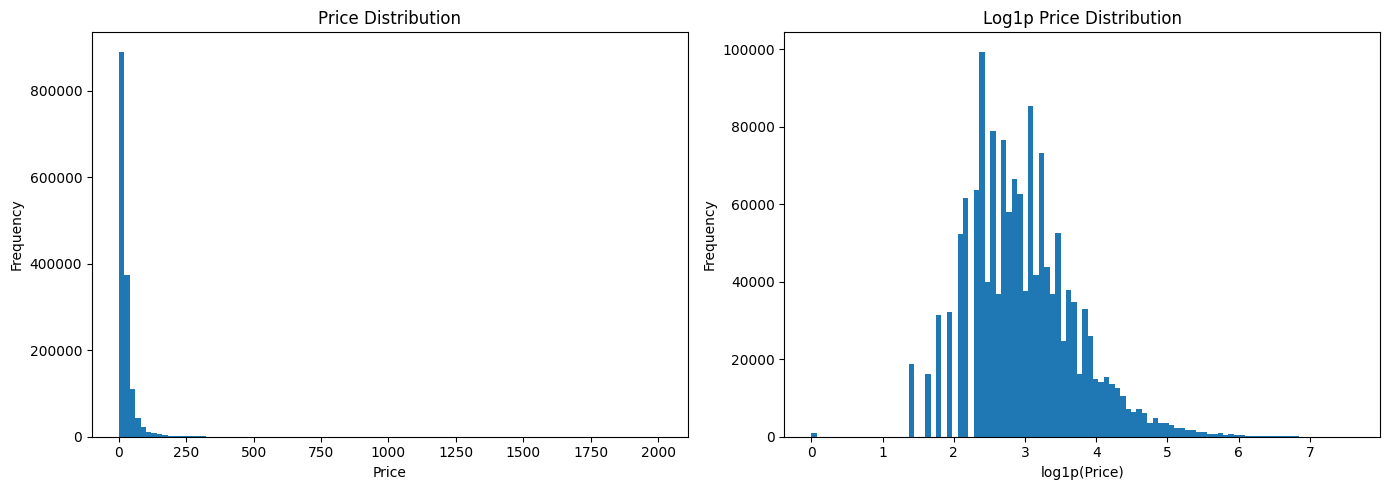

In [14]:
price = train["price"]
log_price = np.log1p(price)

target_summary = pd.DataFrame({
    "price": price.describe(),
    "log1p_price": log_price.describe()
})

print("TARGET SUMMARY")
print(target_summary)

print("\nTARGET SKEWNESS")
print({
    "price": price.skew(),
    "log1p_price": log_price.skew()
})

print("\nTARGET KURTOSIS")
print({
    "price": price.kurtosis(),
    "log1p_price": log_price.kurtosis()
})

print("\nTARGET VALIDITY")
print({
    "zero_prices": (price == 0).sum(),
    "negative_prices": (price < 0).sum(),
    "missing_prices": price.isna().sum()
})

print("\nTARGET PERCENTILES")
print(price.quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(price, bins=100)
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")

axes[1].hist(log_price, bins=100)
axes[1].set_title("Log1p Price Distribution")
axes[1].set_xlabel("log1p(Price)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**2.2 Feature Distribution & Cardinality**

- Inspect unique-value counts for every feature.
- Measure categorical cardinality and missingness rates.
- Inspect frequency distributions of categorical variables.
- Inspect text length distributions for name and item_description.
- Identify rare categories / high-cardinality features.

In [15]:
features = [
    "name",
    "item_condition_id",
    "category_name",
    "brand_name",
    "shipping",
    "item_description"
]

feature_summary = pd.DataFrame({
    "dtype": train[features].dtypes.astype(str),
    "unique_train": train[features].nunique(dropna=False),
    "unique_test": test[features].nunique(dropna=False),
    "missing_train": train[features].isna().sum(),
    "missing_test": test[features].isna().sum()
})

feature_summary["missing_pct_train"] = (
    feature_summary["missing_train"] / len(train) * 100
)

feature_summary["missing_pct_test"] = (
    feature_summary["missing_test"] / len(test) * 100
)

print("FEATURE SUMMARY")
print(feature_summary)

print("\nTOP VALUES - CATEGORICAL FEATURES")

for column in ["item_condition_id", "shipping", "category_name", "brand_name"]:
    print(f"\n{column} - TRAIN")
    print(train[column].value_counts(dropna=False).head(10))

    print(f"{column} - TEST")
    print(test[column].value_counts(dropna=False).head(10))

text_summary = pd.DataFrame(index=["name", "item_description"])

for column in ["name", "item_description"]:
    train_length = train[column].fillna("").str.len()
    test_length = test[column].fillna("").str.len()

    text_summary.loc[column, "train_mean_length"] = train_length.mean()
    text_summary.loc[column, "train_median_length"] = train_length.median()
    text_summary.loc[column, "train_max_length"] = train_length.max()
    text_summary.loc[column, "test_mean_length"] = test_length.mean()
    text_summary.loc[column, "test_median_length"] = test_length.median()
    text_summary.loc[column, "test_max_length"] = test_length.max()

print("\nTEXT LENGTH SUMMARY")
print(text_summary)

print("\nRARE CATEGORY COUNTS")

for column in ["category_name", "brand_name"]:
    frequencies = train[column].value_counts(dropna=False)
    print(f"{column} frequency = 1:", (frequencies == 1).sum())
    print(f"{column} frequency <= 5:", (frequencies <= 5).sum())

FEATURE SUMMARY
                    dtype  unique_train  unique_test  missing_train  \
name               object       1225273       601117              0   
item_condition_id    int8             5            5              0   
category_name      object          1288         1224           6327   
brand_name         object          4810         3901         632682   
shipping             int8             2            2              0   
item_description   object       1281426       609555              6   

                   missing_test  missing_pct_train  missing_pct_test  
name                          0           0.000000          0.000000  
item_condition_id             0           0.000000          0.000000  
category_name              3058           0.426769          0.441041  
brand_name               295525          42.675687         42.622220  
shipping                      0           0.000000          0.000000  
item_description              0           0.000405          

**2.3 Train–Test Distribution Consistency**

- Compare categorical value coverage between train and test.
- Identify categories present only in test or only in train.
- Compare numerical/discrete feature distributions.
- Compare missingness patterns between train and test.
- Identify potential distribution shift.

In [16]:
categorical_features = [
    "item_condition_id",
    "shipping",
    "category_name",
    "brand_name"
]

distribution_report = []

for column in categorical_features:
    train_freq = train[column].value_counts(normalize=True, dropna=False)
    test_freq = test[column].value_counts(normalize=True, dropna=False)

    all_values = train_freq.index.union(test_freq.index)

    train_aligned = train_freq.reindex(all_values, fill_value=0)
    test_aligned = test_freq.reindex(all_values, fill_value=0)

    distribution_report.append({
        "feature": column,
        "train_unique": train[column].nunique(dropna=False),
        "test_unique": test[column].nunique(dropna=False),
        "train_missing_pct": train[column].isna().mean() * 100,
        "test_missing_pct": test[column].isna().mean() * 100,
        "test_only_values": len(set(test[column].dropna().unique()) - set(train[column].dropna().unique())),
        "train_only_values": len(set(train[column].dropna().unique()) - set(test[column].dropna().unique())),
        "max_frequency_difference_pct": (train_aligned - test_aligned).abs().max() * 100
    })

distribution_report = pd.DataFrame(distribution_report)

print("TRAIN-TEST DISTRIBUTION REPORT")
print(distribution_report)

for column in categorical_features:
    train_freq = train[column].value_counts(normalize=True, dropna=False)
    test_freq = test[column].value_counts(normalize=True, dropna=False)

    comparison = pd.concat(
        [
            train_freq.rename("train_pct"),
            test_freq.rename("test_pct")
        ],
        axis=1
    ).fillna(0) * 100

    comparison["abs_difference_pct"] = (
        comparison["train_pct"] - comparison["test_pct"]
    ).abs()

    print(f"\n{column} - TOP DISTRIBUTION DIFFERENCES")
    print(
        comparison
        .sort_values("abs_difference_pct", ascending=False)
        .head(10)
    )

for column in ["name", "item_description"]:
    train_values = set(train[column].dropna().unique())
    test_values = set(test[column].dropna().unique())

    overlap = len(train_values & test_values)

    print(f"\n{column} - EXACT VALUE OVERLAP")
    print("Train unique:", len(train_values))
    print("Test unique:", len(test_values))
    print("Shared values:", overlap)
    print("Test values unseen in train:", len(test_values - train_values))

TRAIN-TEST DISTRIBUTION REPORT
             feature  train_unique  test_unique  train_missing_pct  \
0  item_condition_id             5            5           0.000000   
1           shipping             2            2           0.000000   
2      category_name          1288         1224           0.426769   
3         brand_name          4810         3901          42.675687   

   test_missing_pct  test_only_values  train_only_values  \
0          0.000000                 0                  0   
1          0.000000                 0                  0   
2          0.441041                23                 87   
3         42.622220               480               1389   

   max_frequency_difference_pct  
0                      0.072979  
1                      0.044457  
2                      0.035172  
3                      0.053467  

item_condition_id - TOP DISTRIBUTION DIFFERENCES
                   train_pct   test_pct  abs_difference_pct
item_condition_id                    

**2.4 Data Generation & Split Mechanism**
- Determine whether rows appear independently sampled, temporally ordered, grouped, or otherwise structured.
- Investigate whether IDs, categories, sellers, or other fields imply grouping or ordering.
- Decide what internal validation split best approximates the hidden test-generation process.

In [17]:
train_id = train["train_id"]
test_id = test["test_id"]

id_analysis = pd.DataFrame({
    "train": [
        train_id.min(),
        train_id.max(),
        train_id.nunique(),
        train_id.is_monotonic_increasing,
        train_id.is_monotonic_decreasing,
        train_id.diff().abs().median(),
        train_id.diff().abs().mean()
    ],
    "test": [
        test_id.min(),
        test_id.max(),
        test_id.nunique(),
        test_id.is_monotonic_increasing,
        test_id.is_monotonic_decreasing,
        test_id.diff().abs().median(),
        test_id.diff().abs().mean()
    ]
}, index=[
    "min_id",
    "max_id",
    "unique_ids",
    "monotonic_increasing",
    "monotonic_decreasing",
    "median_absolute_id_step",
    "mean_absolute_id_step"
])

print("ID STRUCTURE")
print(id_analysis)

train_position_id_corr = np.corrcoef(
    np.arange(len(train)),
    train_id
)[0, 1]

test_position_id_corr = np.corrcoef(
    np.arange(len(test)),
    test_id
)[0, 1]

print("\nROW POSITION vs ID CORRELATION")
print({
    "train": train_position_id_corr,
    "test": test_position_id_corr
})

block_data = train.copy()
block_data["row_position"] = np.arange(len(train))
block_data["block"] = pd.qcut(
    block_data["row_position"],
    q=10,
    labels=False
)

target_by_block = block_data.groupby("block")["price"].agg(
    ["count", "mean", "median", "std"]
)

print("\nTARGET BY ROW-ORDER BLOCK")
print(target_by_block)

overall_category = train["category_name"].value_counts(
    normalize=True,
    dropna=False
)

category_block_distribution = pd.crosstab(
    block_data["block"],
    block_data["category_name"],
    normalize="index"
).reindex(columns=overall_category.index, fill_value=0)

category_shift = []

for block in category_block_distribution.index:
    differences = (
        category_block_distribution.loc[block] - overall_category
    ).abs()

    category_shift.append({
        "block": block,
        "total_variation_distance": differences.sum() / 2,
        "max_category_abs_difference": differences.max()
    })

category_shift = pd.DataFrame(category_shift)

print("\nCATEGORY DISTRIBUTION SHIFT BY ROW-ORDER BLOCK")
print(category_shift)

overall_brand = train["brand_name"].value_counts(
    normalize=True,
    dropna=False
)

brand_block_distribution = pd.crosstab(
    block_data["block"],
    block_data["brand_name"],
    normalize="index"
).reindex(columns=overall_brand.index, fill_value=0)

brand_shift = []

for block in brand_block_distribution.index:
    differences = (
        brand_block_distribution.loc[block] - overall_brand
    ).abs()

    brand_shift.append({
        "block": block,
        "total_variation_distance": differences.sum() / 2,
        "max_brand_abs_difference": differences.max()
    })

brand_shift = pd.DataFrame(brand_shift)

print("\nBRAND DISTRIBUTION SHIFT BY ROW-ORDER BLOCK")
print(brand_shift)

missingness_by_block = block_data.groupby("block")[
    ["category_name", "brand_name", "item_description"]
].apply(lambda x: x.isna().mean() * 100)

print("\nMISSINGNESS BY ROW-ORDER BLOCK (%)")
print(missingness_by_block)

ID STRUCTURE
                           train    test
min_id                         0       0
max_id                   1482534  693358
unique_ids               1482535  693359
monotonic_increasing        True    True
monotonic_decreasing       False   False
median_absolute_id_step      1.0     1.0
mean_absolute_id_step        1.0     1.0

ROW POSITION vs ID CORRELATION
{'train': np.float64(1.0), 'test': np.float64(0.9999999999999999)}

TARGET BY ROW-ORDER BLOCK
        count       mean  median        std
block                                      
0      148254  26.659631    17.0  37.791663
1      148253  26.784112    17.0  39.010729
2      148254  26.608800    17.0  38.189784
3      148253  26.705645    17.0  38.384569
4      148254  26.865670    17.0  39.752683
5      148253  26.846995    17.0  38.923776
6      148253  26.692323    17.0  38.110932
7      148254  26.627744    17.0  37.318563
8      148253  26.831342    17.0  39.589228
9      148254  26.752900    17.0  38.719710

CATE

**2.5 Validation Strategy**
- Define the training/validation split.
- Define the exact evaluation metric implementation: RMSLE.
- Establish rules preventing validation leakage.
- Freeze the validation split so experiments remain comparable.

In [18]:
split_train_idx = load_numpy_artifact(
    "split_train_idx",
    SPLIT_CONFIG
)

split_val_idx = load_numpy_artifact(
    "split_val_idx",
    SPLIT_CONFIG
)

if (
    split_train_idx is not None
    and split_val_idx is not None
):
    train_idx = split_train_idx.astype(
        np.int64,
        copy=False
    )
    val_idx = split_val_idx.astype(
        np.int64,
        copy=False
    )

    print("LOADED CACHED VALIDATION SPLIT.")

else:
    train_idx, val_idx = train_test_split(
        np.arange(len(train)),
        test_size=SPLIT_CONFIG["test_size"],
        random_state=SPLIT_CONFIG["random_state"],
        shuffle=SPLIT_CONFIG["shuffle"]
    )

    train_idx = np.asarray(
        train_idx,
        dtype=np.int64
    )
    val_idx = np.asarray(
        val_idx,
        dtype=np.int64
    )

    save_numpy_artifact(
        "split_train_idx",
        train_idx,
        SPLIT_CONFIG
    )

    save_numpy_artifact(
        "split_val_idx",
        val_idx,
        SPLIT_CONFIG
    )

    print("CREATED AND SAVED NEW VALIDATION SPLIT.")

y = train["price"].to_numpy()

y_train = y[train_idx]
y_val = y[val_idx]

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(
        np.mean(
            (
                np.log1p(y_pred)
                - np.log1p(y_true)
            ) ** 2
        )
    )

print("TRAIN ROWS:", len(train_idx))
print("VALIDATION ROWS:", len(val_idx))
print(
    "TRAIN FRACTION:",
    len(train_idx) / len(train)
)
print(
    "VALIDATION FRACTION:",
    len(val_idx) / len(train)
)
print(
    "VALIDATION RANDOM STATE:",
    SPLIT_CONFIG["random_state"]
)
print(
    "TARGET NON-NEGATIVE:",
    np.all(y >= 0)
)
print(
    "TRAIN INDEX HASH:",
    _stable_hash(
        {
            "train_idx_sha256": hashlib.sha256(
                np.ascontiguousarray(train_idx).tobytes()
            ).hexdigest()
        }
    )
)


CREATED AND SAVED NEW VALIDATION SPLIT.
TRAIN ROWS: 1186028
VALIDATION ROWS: 296507
TRAIN FRACTION: 0.8
VALIDATION FRACTION: 0.2
VALIDATION RANDOM STATE: 42
TARGET NON-NEGATIVE: True
TRAIN INDEX HASH: 0a9e6740296d6bcf30ac0d078c3565e7a27b5a278da0d390438e71cf8acab6d9


**2.6 Competition Test Set Isolation**
- Treat test.tsv as the untouched competition test set.
- Ensure no target-derived information from the competition test set enters training or feature engineering.
- Use it only when generating predictions for submission.

In [19]:
competition_test = test.copy(deep=True)

expected_test_columns = [
    "test_id",
    "name",
    "item_condition_id",
    "category_name",
    "brand_name",
    "shipping",
    "item_description"
]

test_snapshot = {
    "rows": len(competition_test),
    "columns": list(competition_test.columns),
    "id_unique": competition_test["test_id"].is_unique,
    "target_present": "price" in competition_test.columns,
    "data_hash": pd.util.hash_pandas_object(
        competition_test,
        index=True
    ).sum()
}

print("COMPETITION TEST SET")
print("Rows:", test_snapshot["rows"])
print("Columns match expected:", test_snapshot["columns"] == expected_test_columns)
print("Test IDs unique:", test_snapshot["id_unique"])
print("Target present:", test_snapshot["target_present"])
print("Snapshot hash:", test_snapshot["data_hash"])

assert test_snapshot["columns"] == expected_test_columns
assert test_snapshot["id_unique"]
assert not test_snapshot["target_present"]

COMPETITION TEST SET
Rows: 693359
Columns match expected: True
Test IDs unique: True
Target present: False
Snapshot hash: 1477444354750877641


# 3. Exploratory Data Analysis & Sanitization

**3.1 Feature Eligibility & Leakage Audit**
- Confirm which columns are legitimate predictive features.
- Exclude train_id / test_id.
- Check for target proxies or post-outcome information.
- Establish the final feature set permitted for modeling.

In [20]:
target = "price"
id_columns = ["train_id", "test_id"]

model_features = [
    column
    for column in train.columns
    if column not in id_columns + [target]
]

proxy_keywords = [
    "price",
    "sold",
    "sale",
    "revenue",
    "transaction",
    "profit",
    "cost"
]

proxy_candidates = [
    column
    for column in model_features
    if any(keyword in column.lower() for keyword in proxy_keywords)
]

train_only_features = sorted(
    set(train.columns) - set(test.columns) - {target, "train_id"}
)

test_only_features = sorted(
    set(test.columns) - set(train.columns) - {"test_id"}
)

print("TARGET:", target)
print("EXCLUDED ID COLUMNS:", id_columns)
print("MODEL FEATURES:", model_features)

print("\nPROXY-TARGET CANDIDATES:", proxy_candidates)
print("UNEXPECTED TRAIN-ONLY FEATURES:", train_only_features)
print("UNEXPECTED TEST-ONLY FEATURES:", test_only_features)

print("\nFEATURE ELIGIBILITY CHECK")
print("Target excluded:", target not in model_features)
print("IDs excluded:", all(column not in model_features for column in id_columns))
print("No proxy candidates:", len(proxy_candidates) == 0)
print("Train/Test feature sets match:", model_features == [
    column for column in test.columns if column != "test_id"
])

TARGET: price
EXCLUDED ID COLUMNS: ['train_id', 'test_id']
MODEL FEATURES: ['name', 'item_condition_id', 'category_name', 'brand_name', 'shipping', 'item_description']

PROXY-TARGET CANDIDATES: []
UNEXPECTED TRAIN-ONLY FEATURES: []
UNEXPECTED TEST-ONLY FEATURES: []

FEATURE ELIGIBILITY CHECK
Target excluded: True
IDs excluded: True
No proxy candidates: True
Train/Test feature sets match: True


**3.2 Variance & Constant-Feature Audit**
- Identify zero-variance features.
- Identify near-zero-variance features.
- Check whether any feature provides effectively no information.

In [21]:
features = [
    "name",
    "item_condition_id",
    "category_name",
    "brand_name",
    "shipping",
    "item_description"
]

variance_report = []

for column in features:
    value_counts = train[column].value_counts(dropna=False)
    unique_count = value_counts.size
    dominant_count = value_counts.iloc[0]
    second_count = value_counts.iloc[1] if unique_count > 1 else 0

    variance_report.append({
        "feature": column,
        "unique_values": unique_count,
        "unique_pct": unique_count / len(train) * 100,
        "dominant_value_pct": dominant_count / len(train) * 100,
        "dominant_to_second_ratio": (
            dominant_count / second_count if second_count > 0 else np.inf
        ),
        "zero_variance": unique_count == 1,
        "near_zero_variance": (
            unique_count / len(train) * 100 < 10
            and (dominant_count / second_count if second_count > 0 else np.inf) > 19
        )
    })

variance_report = pd.DataFrame(variance_report)

print("VARIANCE AUDIT")
print(variance_report)

VARIANCE AUDIT
             feature  unique_values  unique_pct  dominant_value_pct  \
0               name        1225273   82.647155            0.150553   
1  item_condition_id              5    0.000337           43.206332   
2      category_name           1288    0.086878            4.059061   
3         brand_name           4810    0.324444           42.675687   
4           shipping              2    0.000135           55.272557   
5   item_description        1281426   86.434789            5.564051   

   dominant_to_second_ratio  zero_variance  near_zero_variance  
0                  4.927152          False               False  
1                  1.482200          False               False  
2                  1.297477          False               False  
3                 11.697271          False               False  
4                  1.235764          False               False  
5                 20.124177          False               False  


**3.3 Category Hierarchy Analysis**
- Parse category_name into its hierarchical levels.
- Measure missingness and cardinality at each level.
- Check whether hierarchy levels are structurally consistent.
- Preserve the original category path for comparison.

In [22]:
category_train = train["category_name"].str.split("/", expand=True)
category_test = test["category_name"].str.split("/", expand=True)

max_levels = max(
    category_train.shape[1],
    category_test.shape[1]
)

category_train = category_train.reindex(columns=range(max_levels))
category_test = category_test.reindex(columns=range(max_levels))

category_train.columns = [f"category_level_{i+1}" for i in range(max_levels)]
category_test.columns = [f"category_level_{i+1}" for i in range(max_levels)]

train_depth = train["category_name"].str.count("/").add(1)
test_depth = test["category_name"].str.count("/").add(1)

train_depth = train_depth.where(train["category_name"].notna(), 0)
test_depth = test_depth.where(test["category_name"].notna(), 0)

train_depth_dist = train_depth.value_counts(normalize=True).sort_index() * 100
test_depth_dist = test_depth.value_counts(normalize=True).sort_index() * 100

depth_distribution = pd.DataFrame({
    "train_pct": train_depth_dist,
    "test_pct": test_depth_dist
}).fillna(0)

depth_distribution["abs_difference_pct"] = (
    depth_distribution["train_pct"] - depth_distribution["test_pct"]
).abs()

hierarchy_summary = pd.DataFrame({
    "train_unique": category_train.nunique(dropna=False),
    "test_unique": category_test.nunique(dropna=False),
    "train_missing_pct": category_train.isna().mean() * 100,
    "test_missing_pct": category_test.isna().mean() * 100
})

print("CATEGORY HIERARCHY SUMMARY")
print(hierarchy_summary)

print("\nCATEGORY DEPTH DISTRIBUTION (%)")
print(depth_distribution)

print("\nTRAIN MAX DEPTH:", train_depth.max())
print("TEST MAX DEPTH:", test_depth.max())

print("\nCATEGORY LEVEL SAMPLES")
print(category_train.head(10))

print("\nEMPTY CATEGORY COMPONENTS")
train_empty_components = category_train.eq("").sum().sum()
test_empty_components = category_test.eq("").sum().sum()

print("TRAIN:", train_empty_components)
print("TEST:", test_empty_components)

print("\nMISSING INTERMEDIATE LEVELS")

train_intermediate_missing = (
    category_train.iloc[:, 1:].notna()
    & category_train.iloc[:, :-1].isna().values
).sum().sum()

test_intermediate_missing = (
    category_test.iloc[:, 1:].notna()
    & category_test.iloc[:, :-1].isna().values
).sum().sum()

print("TRAIN:", train_intermediate_missing)
print("TEST:", test_intermediate_missing)

CATEGORY HIERARCHY SUMMARY
                  train_unique  test_unique  train_missing_pct  \
category_level_1            11           11           0.426769   
category_level_2           114          114           0.426769   
category_level_3           871          834           0.426769   
category_level_4             8            8          99.703953   
category_level_5             4            4          99.793664   

                  test_missing_pct  
category_level_1          0.441041  
category_level_2          0.441041  
category_level_3          0.441041  
category_level_4         99.704915  
category_level_5         99.795344  

CATEGORY DEPTH DISTRIBUTION (%)
               train_pct   test_pct  abs_difference_pct
category_name                                          
0.0             0.426769   0.441041            0.014272
3.0            99.277184  99.263873            0.013311
4.0             0.089711   0.090429            0.000718
5.0             0.206336   0.204656      

**3.4 Text & Categorical Sanitization Audit**
- Inspect empty strings and whitespace-only values.
- Identify malformed or suspicious categorical/text values.
- Check casing, spacing, and obvious representation inconsistencies.
- Quantify their frequency before deciding whether normalization is warranted.

In [23]:
text_categorical_features = [
    "name",
    "category_name",
    "brand_name",
    "item_description"
]

sanitization_report = []

for column in text_categorical_features:
    train_series = train[column]
    test_series = test[column]

    train_string_mask = train_series.notna() & ~train_series.map(lambda x: isinstance(x, str))
    test_string_mask = test_series.notna() & ~test_series.map(lambda x: isinstance(x, str))

    train_empty = train_series.fillna("").str.strip().eq("").sum()
    test_empty = test_series.fillna("").str.strip().eq("").sum()

    train_whitespace = train_series.fillna("").str.len().gt(
        train_series.fillna("").str.strip().str.len()
    ).sum()

    test_whitespace = test_series.fillna("").str.len().gt(
        test_series.fillna("").str.strip().str.len()
    ).sum()

    sanitization_report.append({
        "feature": column,
        "train_non_string": train_string_mask.sum(),
        "test_non_string": test_string_mask.sum(),
        "train_empty_or_whitespace": train_empty,
        "test_empty_or_whitespace": test_empty,
        "train_whitespace_padded": train_whitespace,
        "test_whitespace_padded": test_whitespace
    })

sanitization_report = pd.DataFrame(sanitization_report)

print("TEXT / CATEGORICAL SANITIZATION AUDIT")
print(sanitization_report)

print("\nEXACT CASE-SENSITIVE VALUE COLLISIONS AFTER STRIP")

for column in text_categorical_features:
    train_clean = train[column].dropna().astype(str).str.strip()
    test_clean = test[column].dropna().astype(str).str.strip()

    train_casefold_groups = train_clean.groupby(train_clean.str.casefold()).nunique()
    test_casefold_groups = test_clean.groupby(test_clean.str.casefold()).nunique()

    train_case_variants = (train_casefold_groups > 1).sum()
    test_case_variants = (test_casefold_groups > 1).sum()

    print(
        f"{column}: "
        f"train={train_case_variants}, "
        f"test={test_case_variants}"
    )

TEXT / CATEGORICAL SANITIZATION AUDIT
            feature  train_non_string  test_non_string  \
0              name                 0                0   
1     category_name                 0                0   
2        brand_name                 0                0   
3  item_description                 0                0   

   train_empty_or_whitespace  test_empty_or_whitespace  \
0                          0                         0   
1                       6327                      3058   
2                     632682                    295525   
3                          6                         0   

   train_whitespace_padded  test_whitespace_padded  
0                        0                       0  
1                        0                       0  
2                        0                       0  
3                        0                       0  

EXACT CASE-SENSITIVE VALUE COLLISIONS AFTER STRIP
name: train=59002, test=25366
category_name: train=0, test=0
bra

**3.5 Near-Duplicate Investigation**
- Identify repeated or highly similar name / item_description patterns where computationally feasible.
- Distinguish legitimate repeated listings from potential duplicates.
- Check for potential leakage through duplicated information across train/validation boundaries.
- Avoid exhaustive pairwise text comparison at this dataset size.

In [24]:
def normalize_text(series):
    return (
        series
        .fillna("")
        .str.lower()
        .str.replace(r"[^a-z0-9]+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

for column in ["name", "item_description"]:
    normalized = normalize_text(train[column])

    duplicate_mask = normalized.duplicated(keep=False) & normalized.ne("")

    duplicate_groups = (
        normalized[duplicate_mask]
        .value_counts()
    )

    print(f"\n{column.upper()}")
    print("Non-empty normalized values:", (normalized != "").sum())
    print("Normalized duplicate rows:", duplicate_mask.sum())
    print("Normalized duplicate groups:", len(duplicate_groups))
    print("Largest normalized duplicate group:", duplicate_groups.iloc[0] if len(duplicate_groups) else 0)

    print("\nTOP NORMALIZED DUPLICATE GROUPS")
    print(duplicate_groups.head(10))

print("\nTRAIN-VALIDATION NORMALIZED NAME OVERLAP")

train_names = normalize_text(train.iloc[train_idx]["name"])
val_names = normalize_text(train.iloc[val_idx]["name"])

train_name_set = set(train_names[train_names.ne("")])
val_name_set = set(val_names[val_names.ne("")])

shared_names = train_name_set & val_name_set

print("Unique normalized train names:", len(train_name_set))
print("Unique normalized validation names:", len(val_name_set))
print("Shared normalized names:", len(shared_names))
print("Validation names seen in train:", len(shared_names) / len(val_name_set) * 100)

print("\nTRAIN-VALIDATION NORMALIZED DESCRIPTION OVERLAP")

train_descriptions = normalize_text(train.iloc[train_idx]["item_description"])
val_descriptions = normalize_text(train.iloc[val_idx]["item_description"])

train_description_set = set(
    train_descriptions[train_descriptions.ne("")]
)

val_description_set = set(
    val_descriptions[val_descriptions.ne("")]
)

shared_descriptions = train_description_set & val_description_set

print("Unique normalized train descriptions:", len(train_description_set))
print("Unique normalized validation descriptions:", len(val_description_set))
print("Shared normalized descriptions:", len(shared_descriptions))
print(
    "Validation descriptions seen in train:",
    len(shared_descriptions) / len(val_description_set) * 100
)


NAME
Non-empty normalized values: 1482516
Normalized duplicate rows: 469283
Normalized duplicate groups: 101539
Largest normalized duplicate group: 3370

TOP NORMALIZED DUPLICATE GROUPS
name
bundle                  3370
lularoe tc leggings     1137
reserved                 935
lularoe os leggings      904
on hold                  730
coach purse              711
miss me jeans            694
american eagle jeans     681
michael kors purse       570
michael kors wallet      498
Name: count, dtype: int64

ITEM_DESCRIPTION
Non-empty normalized values: 1481967
Normalized duplicate rows: 260172
Normalized duplicate groups: 35162
Largest normalized duplicate group: 82498

TOP NORMALIZED DUPLICATE GROUPS
item_description
no description yet    82498
brand new              5079
new                    4878
great condition        1855
good condition         1731
like new               1431
never worn             1370
nwt                    1318
new with tags          1009
never used              

**3.6 Missing-Value Representation**
- Decide how missing categorical/text fields will be represented.
- Define a consistent missing token.
- Determine whether explicit missingness indicators are warranted.
- Ensure transformations are learned only from the training portion.

In [25]:
missing_features = [
    "category_name",
    "brand_name",
    "item_description"
]

missing_value_report = pd.DataFrame({
    "train_missing": train[missing_features].isna().sum(),
    "test_missing": test[missing_features].isna().sum(),
    "train_missing_pct": train[missing_features].isna().mean() * 100,
    "test_missing_pct": test[missing_features].isna().mean() * 100
})

print("MISSING VALUE REPORT")
print(missing_value_report)

print("\nMISSINGNESS INDICATOR COUNTS")

for column in missing_features:
    train_missing = train[column].isna()
    test_missing = test[column].isna()

    print(
        f"{column}: "
        f"train={train_missing.sum()}, "
        f"test={test_missing.sum()}"
    )

print("\nDESCRIPTION PLACEHOLDER CHECK")

description_placeholders = [
    "no description yet"
]

for value in description_placeholders:
    train_count = (
        train["item_description"]
        .fillna("")
        .str.strip()
        .str.lower()
        .eq(value)
        .sum()
    )

    test_count = (
        test["item_description"]
        .fillna("")
        .str.strip()
        .str.lower()
        .eq(value)
        .sum()
    )

    print(
        f"'{value}': "
        f"train={train_count}, "
        f"test={test_count}"
    )

print("\nPLANNED MISSING REPRESENTATION")

missing_representation = {
    "category_name": "Dedicated missing token",
    "brand_name": "Dedicated missing token",
    "item_description": "Dedicated missing state + missingness indicator",
    "text_placeholder": "Convert known placeholder to missing state during text preprocessing"
}

for feature, representation in missing_representation.items():
    print(f"{feature}: {representation}")

MISSING VALUE REPORT
                  train_missing  test_missing  train_missing_pct  \
category_name              6327          3058           0.426769   
brand_name               632682        295525          42.675687   
item_description              6             0           0.000405   

                  test_missing_pct  
category_name             0.441041  
brand_name               42.622220  
item_description          0.000000  

MISSINGNESS INDICATOR COUNTS
category_name: train=6327, test=3058
brand_name: train=632682, test=295525
item_description: train=6, test=0

DESCRIPTION PLACEHOLDER CHECK
'no description yet': train=82494, test=38508

PLANNED MISSING REPRESENTATION
category_name: Dedicated missing token
brand_name: Dedicated missing token
item_description: Dedicated missing state + missingness indicator
text_placeholder: Convert known placeholder to missing state during text preprocessing


**3.7 Target Tail & Zero-Price Review**
- Revisit the 874 zero-price observations.
- Examine the upper-price tail and extreme observations.
- Determine whether unusual values are valid observations or data errors.
- Record an explicit decision on target clipping/winsorization.

In [26]:
price = train["price"]

tail_percentiles = price.quantile([
    0.90,
    0.95,
    0.99,
    0.995,
    0.999,
    0.9995,
    0.9999,
    1.00
])

tail_summary = pd.DataFrame({
    "price": tail_percentiles,
    "count_at_or_above": [
        (price >= threshold).sum()
        for threshold in tail_percentiles
    ]
})

tail_summary["pct_at_or_above"] = (
    tail_summary["count_at_or_above"] / len(price) * 100
)

print("TARGET TAIL SUMMARY")
print(tail_summary)

print("\nZERO-PRICE SUMMARY")
zero_mask = price.eq(0)
nonzero_mask = price.gt(0)

print({
    "zero_price_rows": zero_mask.sum(),
    "zero_price_pct": zero_mask.mean() * 100,
    "positive_price_rows": nonzero_mask.sum(),
    "positive_price_median": price[nonzero_mask].median(),
    "positive_price_mean": price[nonzero_mask].mean()
})

print("\nZERO-PRICE FEATURE PROFILE")

zero_profile = pd.DataFrame({
    "count": [
        zero_mask.sum(),
        train.loc[zero_mask, "brand_name"].isna().sum(),
        train.loc[zero_mask, "category_name"].isna().sum(),
        train.loc[zero_mask, "item_description"].isna().sum()
    ],
    "pct_of_zero_price_rows": [
        100,
        train.loc[zero_mask, "brand_name"].isna().mean() * 100,
        train.loc[zero_mask, "category_name"].isna().mean() * 100,
        train.loc[zero_mask, "item_description"].isna().mean() * 100
    ]
}, index=[
    "zero_price",
    "brand_missing",
    "category_missing",
    "description_missing"
])

print(zero_profile)

print("\nTOP CATEGORIES AMONG ZERO-PRICE ROWS")
print(
    train.loc[zero_mask, "category_name"]
    .value_counts(dropna=False)
    .head(10)
)

print("\nTOP BRANDS AMONG ZERO-PRICE ROWS")
print(
    train.loc[zero_mask, "brand_name"]
    .value_counts(dropna=False)
    .head(10)
)

print("\nTOP ZERO-PRICE NAMES")
print(
    train.loc[zero_mask, "name"]
    .value_counts(dropna=False)
    .head(20)
)

print("\nHIGHEST-PRICE OBSERVATIONS")
print(
    train[
        ["name", "category_name", "brand_name", "item_condition_id", "shipping", "price"]
    ]
    .nlargest(20, "price")
    .to_string(index=False)
)

print("\nPRICE VALUE FREQUENCIES AT UPPER TAIL")
print(
    price[price >= price.quantile(0.99)]
    .value_counts()
    .sort_index()
    .tail(30)
)

TARGET TAIL SUMMARY
           price  count_at_or_above  pct_at_or_above
0.9000    51.000             149836        10.106743
0.9500    75.000              75541         5.095394
0.9900   170.000              15030         1.013804
0.9950   230.330               7413         0.500022
0.9990   450.000               1511         0.101920
0.9995   603.199                742         0.050049
0.9999  1015.000                150         0.010118
1.0000  2009.000                  1         0.000067

ZERO-PRICE SUMMARY
{'zero_price_rows': np.int64(874), 'zero_price_pct': np.float64(0.05895307699312327), 'positive_price_rows': np.int64(1481661), 'positive_price_median': 17.0, 'positive_price_mean': np.float64(26.753288032822624)}

ZERO-PRICE FEATURE PROFILE
                     count  pct_of_zero_price_rows
zero_price             874              100.000000
brand_missing          346               39.588101
category_missing        13                1.487414
description_missing      0           

**3.8 Sanitized Dataset Construction**
- Apply only the integrity-preserving transformations we've decided on.
- Keep the raw ingested datasets untouched.
- Produce modeling-ready train/validation/test representations without target leakage.

In [27]:
train_sanitized = train.copy()
test_sanitized = competition_test.copy()

for df in [train_sanitized, test_sanitized]:
    df["category_name"] = df["category_name"].fillna("__MISSING__")
    df["brand_name"] = df["brand_name"].fillna("__MISSING__")

    description = (
        df["item_description"]
        .fillna("")
        .str.strip()
    )

    description_missing = (
        description.str.lower().eq("no description yet")
        | description.eq("")
    )

    df["item_description_is_missing"] = description_missing.astype("int8")
    df["item_description"] = description.mask(
        description_missing,
        ""
    )

train_sanitized_features = [
    column
    for column in train_sanitized.columns
    if column not in ["train_id", "price"]
]

test_sanitized_features = [
    column
    for column in test_sanitized.columns
    if column != "test_id"
]

print("TRAIN SANITIZED SHAPE:", train_sanitized.shape)
print("TEST SANITIZED SHAPE:", test_sanitized.shape)

print("\nSANITIZED MISSING VALUES")
print(train_sanitized.isna().sum())
print(test_sanitized.isna().sum())

print("\nITEM DESCRIPTION MISSING INDICATOR")
print(
    train_sanitized["item_description_is_missing"].value_counts()
)
print(
    test_sanitized["item_description_is_missing"].value_counts()
)

print("\nPRICE INTEGRITY")
print("Original price unchanged:",
      train["price"].equals(train_sanitized["price"]))

print("\nID INTEGRITY")
print("Train IDs unchanged:",
      train["train_id"].equals(train_sanitized["train_id"]))
print("Test IDs unchanged:",
      test["test_id"].equals(test_sanitized["test_id"]))

print("\nMODEL FEATURE SET")
print(train_sanitized_features)

TRAIN SANITIZED SHAPE: (1482535, 9)
TEST SANITIZED SHAPE: (693359, 8)

SANITIZED MISSING VALUES
train_id                       0
name                           0
item_condition_id              0
category_name                  0
brand_name                     0
price                          0
shipping                       0
item_description               0
item_description_is_missing    0
dtype: int64
test_id                        0
name                           0
item_condition_id              0
category_name                  0
brand_name                     0
shipping                       0
item_description               0
item_description_is_missing    0
dtype: int64

ITEM DESCRIPTION MISSING INDICATOR
item_description_is_missing
0    1400035
1      82500
Name: count, dtype: int64
item_description_is_missing
0    654851
1     38508
Name: count, dtype: int64

PRICE INTEGRITY
Original price unchanged: True

ID INTEGRITY
Train IDs unchanged: True
Test IDs unchanged: True

MODEL FEA

# 4. Initial Baseline

**4.1 Global Median Baseline**
- Predict the same median price for every validation row.
- Establish the absolute minimum reference point for RMSLE.

In [28]:
global_median = np.median(y_train)

y_val_pred_global = np.full(
    shape=len(y_val),
    fill_value=global_median
)

global_median_rmsle = rmsle(
    y_val,
    y_val_pred_global
)

print("GLOBAL MEDIAN:", global_median)
print("VALIDATION RMSLE:", global_median_rmsle)

GLOBAL MEDIAN: 17.0
VALIDATION RMSLE: 0.7565639206244869


**4.2 Single-Feature Group Median Baselines**
- Compute validation-safe median prices grouped by:
    - item_condition_id
    - shipping
    - category_name
    - brand_name
- Use the training partition only to calculate group medians.
- Define a global-median fallback for unseen/missing groups.

In [29]:
baseline_train = train_sanitized.iloc[train_idx].copy()
baseline_val = train_sanitized.iloc[val_idx].copy()

baseline_train["price"] = y_train

group_features = [
    "item_condition_id",
    "shipping",
    "category_name",
    "brand_name"
]

group_baseline_results = []

for feature in group_features:
    global_median = baseline_train["price"].median()

    group_medians = (
        baseline_train
        .groupby(feature, dropna=False)["price"]
        .median()
    )

    y_val_pred = baseline_val[feature].map(group_medians)

    fallback_mask = y_val_pred.isna()
    y_val_pred = y_val_pred.fillna(global_median)

    score = rmsle(
        y_val,
        y_val_pred.to_numpy()
    )

    group_baseline_results.append({
        "feature": feature,
        "rmsle": score,
        "fallback_rows": fallback_mask.sum(),
        "fallback_pct": fallback_mask.mean() * 100,
        "groups": len(group_medians)
    })

group_baseline_results = (
    pd.DataFrame(group_baseline_results)
    .sort_values("rmsle")
    .reset_index(drop=True)
)

print("SINGLE-FEATURE GROUP MEDIAN BASELINES")
print(group_baseline_results)

SINGLE-FEATURE GROUP MEDIAN BASELINES
             feature     rmsle  fallback_rows  fallback_pct  groups
0      category_name  0.658650             30      0.010118    1267
1         brand_name  0.666129            288      0.097131    4557
2           shipping  0.736356              0      0.000000       2
3  item_condition_id  0.757588              0      0.000000       5


**4.3 Multi-Feature Group Median Baseline**
- Test a small number of sensible combinations, primarily:
    - category_name + brand_name
    - category_name + item_condition_id
    - brand_name + item_condition_id
- Again, calculate group statistics using only the training partition.

In [30]:
group_combinations = [
    ["category_name", "brand_name"],
    ["category_name", "item_condition_id"],
    ["brand_name", "item_condition_id"]
]

multi_group_results = []

for features in group_combinations:
    group_medians = (
        baseline_train
        .groupby(features, dropna=False)["price"]
        .median()
    )

    y_val_pred = baseline_val.set_index(features).index.map(group_medians)
    y_val_pred = pd.Series(y_val_pred, index=baseline_val.index)

    fallback_mask = y_val_pred.isna()
    y_val_pred = y_val_pred.fillna(global_median)

    score = rmsle(
        y_val,
        y_val_pred.to_numpy()
    )

    multi_group_results.append({
        "features": " + ".join(features),
        "rmsle": score,
        "fallback_rows": fallback_mask.sum(),
        "fallback_pct": fallback_mask.mean() * 100,
        "groups": len(group_medians)
    })

multi_group_results = (
    pd.DataFrame(multi_group_results)
    .sort_values("rmsle")
    .reset_index(drop=True)
)

print("MULTI-FEATURE GROUP MEDIAN BASELINES")
print(multi_group_results)

MULTI-FEATURE GROUP MEDIAN BASELINES
                            features     rmsle  fallback_rows  fallback_pct  \
0         category_name + brand_name  0.593385           4523      1.525428   
1  category_name + item_condition_id  0.639301            176      0.059358   
2     brand_name + item_condition_id  0.654452            855      0.288357   

   groups  
0   38278  
1    4336  
2   10566  


**4.4 Baseline Comparison**
- Evaluate every baseline using the exact same validation set and RMSLE implementation.
- Record the scores and the coverage/fallback rate of each grouped baseline.
- Select the strongest simple baseline as the reference for subsequent modeling.

*No text features or learned models are involved in Phase 4.*

In [31]:
baseline_comparison = pd.concat([
    pd.DataFrame([{
        "baseline": "global_median",
        "rmsle": global_median_rmsle,
        "fallback_pct": 0.0,
        "groups": 1
    }]),
    group_baseline_results.rename(
        columns={"feature": "baseline"}
    )[["baseline", "rmsle", "fallback_pct", "groups"]],
    multi_group_results.rename(
        columns={"features": "baseline"}
    )[["baseline", "rmsle", "fallback_pct", "groups"]]
], ignore_index=True)

baseline_comparison["improvement_vs_global"] = (
    global_median_rmsle - baseline_comparison["rmsle"]
)

baseline_comparison = (
    baseline_comparison
    .sort_values("rmsle")
    .reset_index(drop=True)
)

print("BASELINE COMPARISON")
print(baseline_comparison)

best_baseline = baseline_comparison.iloc[0]

print("\nBEST BASELINE")
print("Baseline:", best_baseline["baseline"])
print("RMSLE:", best_baseline["rmsle"])
print("Improvement vs global:", best_baseline["improvement_vs_global"])
print("Fallback:", best_baseline["fallback_pct"], "%")

save_dataframe_json_artifact(
    "baseline_comparison",
    baseline_comparison,
    {
        "data_fingerprint": DATA_FINGERPRINT,
        "split_config": SPLIT_CONFIG
    }
)


BASELINE COMPARISON
                            baseline     rmsle  fallback_pct  groups  \
0         category_name + brand_name  0.593385      1.525428   38278   
1  category_name + item_condition_id  0.639301      0.059358    4336   
2     brand_name + item_condition_id  0.654452      0.288357   10566   
3                      category_name  0.658650      0.010118    1267   
4                         brand_name  0.666129      0.097131    4557   
5                           shipping  0.736356      0.000000       2   
6                      global_median  0.756564      0.000000       1   
7                  item_condition_id  0.757588      0.000000       5   

   improvement_vs_global  
0               0.163179  
1               0.117263  
2               0.102112  
3               0.097914  
4               0.090435  
5               0.020208  
6               0.000000  
7              -0.001024  

BEST BASELINE
Baseline: category_name + brand_name
RMSLE: 0.5933847755280435
Improvemen

# 5. Feature Engineering

**5.1 Leakage-Safe Preprocessing**
- Define transformations separately from raw data.
- Ensure anything learned from data uses training partition only.
- Ensure identical transformations are applied to train, validation, and competition test.
- Keep raw and sanitized datasets untouched.

In [32]:
X_train = train_sanitized.iloc[train_idx].copy()
X_val = train_sanitized.iloc[val_idx].copy()
X_test = test_sanitized.copy()

y_train = train_sanitized.iloc[train_idx]["price"].copy()
y_val = train_sanitized.iloc[val_idx]["price"].copy()

model_features = [
    "name",
    "item_condition_id",
    "category_name",
    "brand_name",
    "shipping",
    "item_description",
    "item_description_is_missing"
]

X_train = X_train[model_features]
X_val = X_val[model_features]
X_test = X_test[model_features]

print("TRAIN SHAPE:", X_train.shape)
print("VALIDATION SHAPE:", X_val.shape)
print("TEST SHAPE:", X_test.shape)

print("\nTARGET SHAPES")
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

print("\nFEATURE CONSISTENCY")
print("Train = Val:", list(X_train.columns) == list(X_val.columns))
print("Train = Test:", list(X_train.columns) == list(X_test.columns))

print("\nTARGET LEAKAGE CHECK")
print("Price in X_train:", "price" in X_train.columns)
print("Price in X_val:", "price" in X_val.columns)
print("Price in X_test:", "price" in X_test.columns)

print("\nROW OVERLAP CHECK")
print(
    "Train/Validation overlap:",
    len(set(train_idx) & set(val_idx))
)

TRAIN SHAPE: (1186028, 7)
VALIDATION SHAPE: (296507, 7)
TEST SHAPE: (693359, 7)

TARGET SHAPES
y_train: (1186028,)
y_val: (296507,)

FEATURE CONSISTENCY
Train = Val: True
Train = Test: True

TARGET LEAKAGE CHECK
Price in X_train: False
Price in X_val: False
Price in X_test: False

ROW OVERLAP CHECK
Train/Validation overlap: 0


**5.2 Category Hierarchy Features**
- Extract category_level_1 through category_level_5.
- Preserve the original full category_name.
- Handle missing hierarchy explicitly.
- Measure whether individual levels add information beyond the full category path.

In [33]:
def add_category_levels(df):
    levels = df["category_name"].str.split("/", expand=True)

    levels = levels.reindex(columns=range(5))
    levels.columns = [
        "category_level_1",
        "category_level_2",
        "category_level_3",
        "category_level_4",
        "category_level_5"
    ]

    levels = levels.fillna("__MISSING__")

    return pd.concat(
        [df.reset_index(drop=True), levels.reset_index(drop=True)],
        axis=1
    )


X_train_cat = add_category_levels(X_train)
X_val_cat = add_category_levels(X_val)
X_test_cat = add_category_levels(X_test)

category_levels = [
    "category_level_1",
    "category_level_2",
    "category_level_3",
    "category_level_4",
    "category_level_5"
]

category_summary = pd.DataFrame({
    "train_unique": X_train_cat[category_levels].nunique(),
    "val_unique": X_val_cat[category_levels].nunique(),
    "test_unique": X_test_cat[category_levels].nunique(),
    "train_missing": X_train_cat[category_levels].eq("__MISSING__").sum(),
    "val_missing": X_val_cat[category_levels].eq("__MISSING__").sum(),
    "test_missing": X_test_cat[category_levels].eq("__MISSING__").sum()
})

print("CATEGORY LEVEL SUMMARY")
print(category_summary)

print("\nFEATURE CONSISTENCY")
print("Train = Val:", list(X_train_cat.columns) == list(X_val_cat.columns))
print("Train = Test:", list(X_train_cat.columns) == list(X_test_cat.columns))

print("\nCATEGORY LEVEL SAMPLES")
print(
    X_train_cat[
        ["category_name"] + category_levels
    ].head(10)
)

CATEGORY LEVEL SUMMARY
                  train_unique  val_unique  test_unique  train_missing  \
category_level_1            11          11           11           5083   
category_level_2           114         114          114           5083   
category_level_3           859         780          834           5083   
category_level_4             7           6            7        1182543   
category_level_5             3           3            3        1183600   

                  val_missing  test_missing  
category_level_1         1244          3058  
category_level_2         1244          3058  
category_level_3         1244          3058  
category_level_4       295603        691313  
category_level_5       295876        691940  

FEATURE CONSISTENCY
Train = Val: True
Train = Test: True

CATEGORY LEVEL SAMPLES
                                    category_name   category_level_1  \
0                          Kids/Boys (4+)/Bottoms               Kids   
1                             

**5.3 Categorical Interaction Features**
- Construct only the empirically motivated combinations:
    - category_name + brand_name
    - category_name + item_condition_id
    - brand_name + item_condition_id
- Avoid arbitrary interaction explosion.
- Compare their incremental value against the existing category + brand baseline.

In [34]:
interaction_specs = {
    "category_brand": ["category_name", "brand_name"],
    "category_condition": ["category_name", "item_condition_id"],
    "brand_condition": ["brand_name", "item_condition_id"]
}

for name, columns in interaction_specs.items():
    X_train_cat[name] = X_train_cat[columns].astype(str).agg("|".join, axis=1)
    X_val_cat[name] = X_val_cat[columns].astype(str).agg("|".join, axis=1)
    X_test_cat[name] = X_test_cat[columns].astype(str).agg("|".join, axis=1)

interaction_features = list(interaction_specs.keys())

interaction_summary = pd.DataFrame({
    "train_unique": X_train_cat[interaction_features].nunique(),
    "val_unique": X_val_cat[interaction_features].nunique(),
    "test_unique": X_test_cat[interaction_features].nunique()
})

print("INTERACTION FEATURE SUMMARY")
print(interaction_summary)

print("\nTRAIN-VALIDATION-TEST FEATURE CONSISTENCY")
print(
    "Train = Val:",
    list(X_train_cat.columns) == list(X_val_cat.columns)
)
print(
    "Train = Test:",
    list(X_train_cat.columns) == list(X_test_cat.columns)
)

print("\nINTERACTION SAMPLES")
print(
    X_train_cat[
        ["category_name", "brand_name", "item_condition_id"] + interaction_features
    ].head(10)
)

INTERACTION FEATURE SUMMARY
                    train_unique  val_unique  test_unique
category_brand             38278       19374        29859
category_condition          4336        3470         4041
brand_condition            10566        6313         8805

TRAIN-VALIDATION-TEST FEATURE CONSISTENCY
Train = Val: True
Train = Test: True

INTERACTION SAMPLES
                                    category_name         brand_name  \
0                          Kids/Boys (4+)/Bottoms        __MISSING__   
1                               Other/Other/Other        __MISSING__   
2               Beauty/Hair Care/Styling Products        __MISSING__   
3                        Women/Pants/Casual Pants        __MISSING__   
4                         Women/Underwear/Panties               PINK   
5                              Beauty/Makeup/Lips        __MISSING__   
6                             Women/Shoes/Sandals        __MISSING__   
7                               Women/Shoes/Boots  Report Colle

**5.4 Frequency Features**
- Calculate occurrence counts/frequencies for:
    - brand_name
    - category_name
    - category_name + brand_name
- Use training-only counts for validation/test transformation.
- Evaluate whether rarity/frequency provides signal beyond categorical identity.

In [35]:
frequency_features = {
    "brand_count": "brand_name",
    "category_count": "category_name",
    "category_brand_count": "category_brand"
}

frequency_summary = []

for feature_name, source_column in frequency_features.items():
    counts = X_train_cat[source_column].value_counts(dropna=False)

    X_train_cat[feature_name] = X_train_cat[source_column].map(counts).astype("int32")
    X_val_cat[feature_name] = (
        X_val_cat[source_column]
        .map(counts)
        .fillna(0)
        .astype("int32")
    )
    X_test_cat[feature_name] = (
        X_test_cat[source_column]
        .map(counts)
        .fillna(0)
        .astype("int32")
    )

    frequency_summary.append({
        "feature": feature_name,
        "train_min": X_train_cat[feature_name].min(),
        "train_median": X_train_cat[feature_name].median(),
        "train_max": X_train_cat[feature_name].max(),
        "val_unseen_groups": (X_val_cat[feature_name] == 0).sum(),
        "test_unseen_groups": (X_test_cat[feature_name] == 0).sum()
    })

frequency_summary = pd.DataFrame(frequency_summary)

print("FREQUENCY FEATURE SUMMARY")
print(frequency_summary)

print("\nFEATURE SAMPLES")
print(
    X_train_cat[
        [
            "brand_name",
            "category_name",
            "category_brand",
            "brand_count",
            "category_count",
            "category_brand_count"
        ]
    ].head(10)
)

FREQUENCY FEATURE SUMMARY
                feature  train_min  train_median  train_max  \
0           brand_count          1       38489.0     506058   
1        category_count          1        6903.0      48164   
2  category_brand_count          1        1107.0      18985   

   val_unseen_groups  test_unseen_groups  
0                288                 728  
1                 30                  45  
2               4523               10849  

FEATURE SAMPLES
          brand_name                                   category_name  \
0        __MISSING__                          Kids/Boys (4+)/Bottoms   
1        __MISSING__                               Other/Other/Other   
2        __MISSING__               Beauty/Hair Care/Styling Products   
3        __MISSING__                        Women/Pants/Casual Pants   
4               PINK                         Women/Underwear/Panties   
5        __MISSING__                              Beauty/Makeup/Lips   
6        __MISSING__        

**5.5 Lightweight Text Statistics**
- Extract a small set of cheap statistics from name and item_description:
    - character count
    - word count
    - digit count
- Preserve the existing item_description_is_missing.
- Avoid large handcrafted NLP feature sets.

In [36]:
text_columns = {
    "name": "name",
    "item_description": "item_description"
}

for feature, column in text_columns.items():
    for split_name, df in [
        ("train", X_train_cat),
        ("val", X_val_cat),
        ("test", X_test_cat)
    ]:
        text = df[column].fillna("")

        df[f"{feature}_char_count"] = text.str.len().astype("int32")
        df[f"{feature}_word_count"] = text.str.split().str.len().astype("int16")
        df[f"{feature}_digit_count"] = (
            text.str.count(r"\d").astype("int16")
        )

text_stat_features = [
    "name_char_count",
    "name_word_count",
    "name_digit_count",
    "item_description_char_count",
    "item_description_word_count",
    "item_description_digit_count"
]

text_stats_summary = pd.DataFrame({
    "train_mean": X_train_cat[text_stat_features].mean(),
    "train_median": X_train_cat[text_stat_features].median(),
    "train_max": X_train_cat[text_stat_features].max(),
    "val_mean": X_val_cat[text_stat_features].mean(),
    "test_mean": X_test_cat[text_stat_features].mean()
})

print("TEXT STATISTICS SUMMARY")
print(text_stats_summary)

print("\nFEATURE CONSISTENCY")
print("Train = Val:", list(X_train_cat.columns) == list(X_val_cat.columns))
print("Train = Test:", list(X_train_cat.columns) == list(X_test_cat.columns))

print("\nTEXT STATISTIC SAMPLES")
print(
    X_train_cat[
        ["name", "item_description"] + text_stat_features
    ].head(10)
)

TEXT STATISTICS SUMMARY
                              train_mean  train_median  train_max    val_mean  \
name_char_count                25.783017          26.0         43   25.799920   
name_word_count                 4.400610           4.0         17    4.401893   
name_digit_count                0.462080           0.0         24    0.459014   
item_description_char_count   144.644336          85.5       1046  144.971491   
item_description_word_count    25.512897          15.0        245   25.556655   
item_description_digit_count    2.121795           0.0        486    2.127333   

                               test_mean  
name_char_count                25.779492  
name_word_count                 4.398404  
name_digit_count                0.460656  
item_description_char_count   144.534439  
item_description_word_count    25.499394  
item_description_digit_count    2.120310  

FEATURE CONSISTENCY
Train = Val: True
Train = Test: True

TEXT STATISTIC SAMPLES
                         

**5.6 TF-IDF Text Representation**
- Normalize name and item_description.
- Build sparse TF-IDF representations.
- Restrict vocabulary/n-gram size to respect the runtime and memory budget.
- Fit the TF-IDF vocabulary using training data only.
- Use the resulting representations for the planned Ridge benchmark.

In [37]:
def prepare_text(series):
    return (
        series
        .fillna("")
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


name_train_text = prepare_text(
    X_train_cat["name"]
)
name_val_text = prepare_text(
    X_val_cat["name"]
)
name_test_text = prepare_text(
    X_test_cat["name"]
)

description_train_text = prepare_text(
    X_train_cat["item_description"]
)
description_val_text = prepare_text(
    X_val_cat["item_description"]
)
description_test_text = prepare_text(
    X_test_cat["item_description"]
)

name_vectorizer_config = {
    "text_column": "name",
    **TFIDF_CONFIG
}

description_vectorizer_config = {
    "text_column": "item_description",
    **TFIDF_CONFIG
}

name_vectorizer = load_joblib_artifact(
    "name_tfidf_vectorizer",
    name_vectorizer_config
)

description_vectorizer = load_joblib_artifact(
    "description_tfidf_vectorizer",
    description_vectorizer_config
)

if (
    name_vectorizer is None
    or description_vectorizer is None
):
    name_vectorizer = TfidfVectorizer(
        ngram_range=tuple(
            TFIDF_CONFIG["ngram_range"]
        ),
        max_features=TFIDF_CONFIG["max_features"],
        min_df=TFIDF_CONFIG["min_df"],
        max_df=TFIDF_CONFIG["max_df"],
        dtype=np.float32
    )

    description_vectorizer = TfidfVectorizer(
        ngram_range=tuple(
            TFIDF_CONFIG["ngram_range"]
        ),
        max_features=TFIDF_CONFIG["max_features"],
        min_df=TFIDF_CONFIG["min_df"],
        max_df=TFIDF_CONFIG["max_df"],
        dtype=np.float32
    )

    name_train_tfidf = (
        name_vectorizer.fit_transform(
            name_train_text
        )
    )

    description_train_tfidf = (
        description_vectorizer.fit_transform(
            description_train_text
        )
    )

    save_joblib_artifact(
        "name_tfidf_vectorizer",
        name_vectorizer,
        name_vectorizer_config
    )

    save_joblib_artifact(
        "description_tfidf_vectorizer",
        description_vectorizer,
        description_vectorizer_config
    )

    print(
        "FITTED AND SAVED TF-IDF VECTORIZERS."
    )

else:
    name_train_tfidf = (
        name_vectorizer.transform(
            name_train_text
        )
    )

    description_train_tfidf = (
        description_vectorizer.transform(
            description_train_text
        )
    )

    print(
        "LOADED CACHED TF-IDF VECTORIZERS."
    )

name_val_tfidf = (
    name_vectorizer.transform(
        name_val_text
    )
)

name_test_tfidf = (
    name_vectorizer.transform(
        name_test_text
    )
)

description_val_tfidf = (
    description_vectorizer.transform(
        description_val_text
    )
)

description_test_tfidf = (
    description_vectorizer.transform(
        description_test_text
    )
)

X_train_text = hstack(
    [
        name_train_tfidf,
        description_train_tfidf
    ],
    format="csr",
    dtype=np.float32
)

X_val_text = hstack(
    [
        name_val_tfidf,
        description_val_tfidf
    ],
    format="csr",
    dtype=np.float32
)

X_test_text = hstack(
    [
        name_test_tfidf,
        description_test_tfidf
    ],
    format="csr",
    dtype=np.float32
)

print("NAME TF-IDF")
print("Train shape:", name_train_tfidf.shape)
print("Validation shape:", name_val_tfidf.shape)
print("Test shape:", name_test_tfidf.shape)
print(
    "Vocabulary size:",
    len(name_vectorizer.vocabulary_)
)
print(
    "Train non-zero values:",
    name_train_tfidf.nnz
)

print("\nDESCRIPTION TF-IDF")
print(
    "Train shape:",
    description_train_tfidf.shape
)
print(
    "Validation shape:",
    description_val_tfidf.shape
)
print(
    "Test shape:",
    description_test_tfidf.shape
)
print(
    "Vocabulary size:",
    len(description_vectorizer.vocabulary_)
)
print(
    "Train non-zero values:",
    description_train_tfidf.nnz
)

print("\nCOMBINED TF-IDF")
print(
    "Train shape:",
    X_train_text.shape
)
print(
    "Validation shape:",
    X_val_text.shape
)
print(
    "Test shape:",
    X_test_text.shape
)
print(
    "Train non-zero values:",
    X_train_text.nnz
)


FITTED AND SAVED TF-IDF VECTORIZERS.
NAME TF-IDF
Train shape: (1186028, 5000)
Validation shape: (296507, 5000)
Test shape: (693359, 5000)
Vocabulary size: 5000
Train non-zero values: 5352764

DESCRIPTION TF-IDF
Train shape: (1186028, 5000)
Validation shape: (296507, 5000)
Test shape: (693359, 5000)
Vocabulary size: 5000
Train non-zero values: 29070845

COMBINED TF-IDF
Train shape: (1186028, 10000)
Validation shape: (296507, 10000)
Test shape: (693359, 10000)
Train non-zero values: 34423609


**5.7 Feature-Family Experiments**
- Evaluate each feature family incrementally against the current RMSLE benchmark.
- Keep only feature families that demonstrate measurable validation value.
- Avoid retaining features solely because they are theoretically plausible.

In [38]:
feature_families = {
    "original_structured": [
        "item_condition_id",
        "shipping",
        "category_name",
        "brand_name"
    ],
    "category_hierarchy": [
        "category_level_1",
        "category_level_2",
        "category_level_3",
        "category_level_4",
        "category_level_5"
    ],
    "categorical_interactions": [
        "category_brand",
        "category_condition",
        "brand_condition"
    ],
    "frequency_features": [
        "brand_count",
        "category_count",
        "category_brand_count"
    ],
    "text_statistics": [
        "name_char_count",
        "name_word_count",
        "name_digit_count",
        "item_description_char_count",
        "item_description_word_count",
        "item_description_digit_count"
    ],
    "text_representation": [
        "name_tfidf",
        "item_description_tfidf"
    ],
    "missingness": [
        "item_description_is_missing"
    ]
}

feature_family_report = []

for family, features in feature_families.items():
    if family == "text_representation":
        train_shape = X_train_text.shape
        val_shape = X_val_text.shape
        test_shape = X_test_text.shape
        train_nonzero = X_train_text.nnz

    else:
        available = all(
            feature in X_train_cat.columns
            for feature in features
        )

        train_shape = (
            X_train_cat[features].shape
            if available
            else None
        )

        val_shape = (
            X_val_cat[features].shape
            if available
            else None
        )

        test_shape = (
            X_test_cat[features].shape
            if available
            else None
        )

        train_nonzero = None

    feature_family_report.append({
        "family": family,
        "features": len(features),
        "available": (
            True
            if family == "text_representation"
            else all(feature in X_train_cat.columns for feature in features)
        ),
        "train_shape": train_shape,
        "val_shape": val_shape,
        "test_shape": test_shape,
        "train_nonzero": train_nonzero
    })

feature_family_report = pd.DataFrame(feature_family_report)

print("FEATURE FAMILY READINESS")
print(feature_family_report)

print("\nFEATURE FAMILY STATUS")

for family, row in feature_family_report.iterrows():
    print(
        row["family"],
        "→",
        "READY" if row["available"] else "MISSING FEATURES"
    )

print("\nEXPECTED EXPERIMENT ORDER")

for i, family in enumerate([
    "original_structured",
    "category_hierarchy",
    "categorical_interactions",
    "frequency_features",
    "text_statistics",
    "text_representation",
    "missingness"
], 1):
    print(f"{i}. {family}")

FEATURE FAMILY READINESS
                     family  features  available       train_shape  \
0       original_structured         4       True      (1186028, 4)   
1        category_hierarchy         5       True      (1186028, 5)   
2  categorical_interactions         3       True      (1186028, 3)   
3        frequency_features         3       True      (1186028, 3)   
4           text_statistics         6       True      (1186028, 6)   
5       text_representation         2       True  (1186028, 10000)   
6               missingness         1       True      (1186028, 1)   

         val_shape       test_shape  train_nonzero  
0      (296507, 4)      (693359, 4)            NaN  
1      (296507, 5)      (693359, 5)            NaN  
2      (296507, 3)      (693359, 3)            NaN  
3      (296507, 3)      (693359, 3)            NaN  
4      (296507, 6)      (693359, 6)            NaN  
5  (296507, 10000)  (693359, 10000)     34423609.0  
6      (296507, 1)      (693359, 1)        

# 6. Iterative Model Benchmarking

**6.1 Benchmark Setup**
- Freeze the current validation split.
- Freeze the RMSLE implementation.
- Define a consistent experiment-recording format.
- Establish 0.593385 (category_name + brand_name median) as the current benchmark.

In [39]:
# Reconstruct targets directly from the persisted split.
y_train = train_sanitized.iloc[
    train_idx
]["price"].to_numpy()

y_val = train_sanitized.iloc[
    val_idx
]["price"].to_numpy()

y_train_log = np.log1p(
    y_train
)

y_val_log = np.log1p(
    y_val
)

# Recompute the category + brand benchmark from the actual data.
benchmark_train = train_sanitized.iloc[
    train_idx
][
    [
        "category_name",
        "brand_name",
        "price"
    ]
].copy()

benchmark_val = train_sanitized.iloc[
    val_idx
][
    [
        "category_name",
        "brand_name"
    ]
].copy()

benchmark_medians = (
    benchmark_train
    .groupby(
        ["category_name", "brand_name"],
        dropna=False
    )["price"]
    .median()
)

benchmark_pred = benchmark_val.set_index(
    ["category_name", "brand_name"]
).index.map(
    benchmark_medians
)

benchmark_pred = pd.Series(
    benchmark_pred,
    index=benchmark_val.index
).fillna(
    benchmark_train["price"].median()
)

benchmark_rmsle = rmsle(
    y_val,
    benchmark_pred.to_numpy()
)

experiment_registry_config = {
    "data_fingerprint": DATA_FINGERPRINT,
    "split_config": SPLIT_CONFIG,
    "registry_schema_version": 1
}

loaded_experiments = load_json_artifact(
    "experiment_registry",
    experiment_registry_config
)

if loaded_experiments is None:
    experiments = []
    print(
        "NO COMPATIBLE EXPERIMENT REGISTRY FOUND."
    )
else:
    experiments = loaded_experiments
    print(
        "LOADED CACHED EXPERIMENT REGISTRY:",
        len(experiments),
        "experiments"
    )


def record_experiment(
    name,
    score,
    runtime=None
):
    global experiments

    record = {
        "model": name,
        "rmsle": float(score),
        "improvement_vs_benchmark": float(
            benchmark_rmsle - score
        ),
        "runtime_seconds": (
            None
            if runtime is None
            else float(runtime)
        )
    }

    # A model name identifies one experiment in this notebook.
    # Re-running a cached experiment updates the existing record
    # instead of creating duplicates.
    experiments = [
        row
        for row in experiments
        if row.get("model") != name
    ]

    experiments.append(
        record
    )

    save_json_artifact(
        "experiment_registry",
        experiments,
        experiment_registry_config
    )


print("BENCHMARK RMSLE:", benchmark_rmsle)

print("\nVALIDATION SET")
print("Rows:", len(y_val))
print("Target rows:", len(y_val))
print("Same length:", len(y_val) == len(val_idx))

print("\nTARGET TRANSFORMATION")
print(
    "Training target transformed:",
    len(y_train_log) == len(y_train)
)
print(
    "Validation target transformed:",
    len(y_val_log) == len(y_val)
)

print("\nEXPERIMENT REGISTRY")
print(
    "Experiments recorded:",
    len(experiments)
)


NO COMPATIBLE EXPERIMENT REGISTRY FOUND.
BENCHMARK RMSLE: 0.5933847755280435

VALIDATION SET
Rows: 296507
Target rows: 296507
Same length: True

TARGET TRANSFORMATION
Training target transformed: True
Validation target transformed: True

EXPERIMENT REGISTRY
Experiments recorded: 0


**6.2 TF-IDF + Ridge: Text-Only Benchmark**
- Use name TF-IDF + item_description TF-IDF.
- Transform the target with log1p(price).
- Train Ridge on the training partition.
- Convert predictions back with expm1.
- Evaluate RMSLE on validation.

In [40]:
ridge_config = {
    "model": "Ridge",
    "alpha": 1.0,
    "solver": "lsqr",
    "data_fingerprint": DATA_FINGERPRINT,
    "split_config": SPLIT_CONFIG,
    "tfidf_config": TFIDF_CONFIG
}

ridge = load_joblib_artifact(
    "tfidf_ridge_model",
    ridge_config
)

if ridge is None:
    ridge = Ridge(
        alpha=1.0,
        solver="lsqr"
    )

    start = perf_counter()

    ridge.fit(
        X_train_text,
        y_train_log
    )

    train_runtime = (
        perf_counter() - start
    )

    save_joblib_artifact(
        "tfidf_ridge_model",
        ridge,
        ridge_config
    )

    print(
        "TRAINED AND SAVED TF-IDF + RIDGE."
    )

else:
    train_runtime = None

    print(
        "LOADED CACHED TF-IDF + RIDGE."
    )

y_val_log_pred = ridge.predict(
    X_val_text
)

y_val_pred = np.maximum(
    np.expm1(
        y_val_log_pred
    ),
    0
)

ridge_rmsle = rmsle(
    y_val,
    y_val_pred
)

if not any(
    row.get("model") == "TF-IDF + Ridge"
    for row in experiments
):
    record_experiment(
        name="TF-IDF + Ridge",
        score=ridge_rmsle,
        runtime=train_runtime
    )

print("MODEL: TF-IDF + Ridge")
print(
    "ALPHA:",
    ridge.alpha
)
print(
    "TRAIN RUNTIME (SECONDS):",
    train_runtime
)
print(
    "VALIDATION RMSLE:",
    ridge_rmsle
)
print(
    "IMPROVEMENT VS BENCHMARK:",
    benchmark_rmsle - ridge_rmsle
)


TRAINED AND SAVED TF-IDF + RIDGE.
MODEL: TF-IDF + Ridge
ALPHA: 1.0
TRAIN RUNTIME (SECONDS): 9.173749461999932
VALIDATION RMSLE: 0.5323966404102851
IMPROVEMENT VS BENCHMARK: 0.06098813511775836


**6.3 TF-IDF + Ridge: Structured + Text**
- Add the most useful structured features to the TF-IDF representation.
- Include category hierarchy, interactions, frequency features, and lightweight text statistics as appropriate.
- Measure the incremental improvement over the text-only model and the 0.593385 categorical baseline.

In [41]:
categorical_features = [
    "item_condition_id",
    "shipping",
    "category_name",
    "brand_name",
    "category_level_1",
    "category_level_2",
    "category_level_3",
    "category_level_4",
    "category_level_5",
    "category_brand",
    "category_condition",
    "brand_condition"
]

numeric_features = [
    "brand_count",
    "category_count",
    "category_brand_count",
    "name_char_count",
    "name_word_count",
    "name_digit_count",
    "item_description_char_count",
    "item_description_word_count",
    "item_description_digit_count",
    "item_description_is_missing"
]

combined_preprocessing_config = {
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "data_fingerprint": DATA_FINGERPRINT,
    "split_config": SPLIT_CONFIG,
    "ridge": {
        "alpha": 1.0,
        "solver": "lsqr"
    },
    "tfidf_config": TFIDF_CONFIG
}

categorical_encoder = load_joblib_artifact(
    "combined_ohe_encoder",
    combined_preprocessing_config
)

numeric_scaler = load_joblib_artifact(
    "combined_numeric_scaler",
    combined_preprocessing_config
)

ridge_combined = load_joblib_artifact(
    "combined_ridge_model",
    combined_preprocessing_config
)

start = perf_counter()

if (
    categorical_encoder is None
    or numeric_scaler is None
):
    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
        dtype=np.float32
    )

    numeric_scaler = StandardScaler(
        with_mean=False
    )

    X_train_cat_ohe = (
        categorical_encoder.fit_transform(
            X_train_cat[
                categorical_features
            ]
        )
    )

    X_val_cat_ohe = (
        categorical_encoder.transform(
            X_val_cat[
                categorical_features
            ]
        )
    )

    X_test_cat_ohe = (
        categorical_encoder.transform(
            X_test_cat[
                categorical_features
            ]
        )
    )

    X_train_num = numeric_scaler.fit_transform(
        X_train_cat[
            numeric_features
        ].astype(np.float32)
    )

    X_val_num = numeric_scaler.transform(
        X_val_cat[
            numeric_features
        ].astype(np.float32)
    )

    X_test_num = numeric_scaler.transform(
        X_test_cat[
            numeric_features
        ].astype(np.float32)
    )

    save_joblib_artifact(
        "combined_ohe_encoder",
        categorical_encoder,
        combined_preprocessing_config
    )

    save_joblib_artifact(
        "combined_numeric_scaler",
        numeric_scaler,
        combined_preprocessing_config
    )

    print(
        "FITTED AND SAVED STRUCTURED PREPROCESSORS."
    )

else:
    X_train_cat_ohe = (
        categorical_encoder.transform(
            X_train_cat[
                categorical_features
            ]
        )
    )

    X_val_cat_ohe = (
        categorical_encoder.transform(
            X_val_cat[
                categorical_features
            ]
        )
    )

    X_test_cat_ohe = (
        categorical_encoder.transform(
            X_test_cat[
                categorical_features
            ]
        )
    )

    X_train_num = numeric_scaler.transform(
        X_train_cat[
            numeric_features
        ].astype(np.float32)
    )

    X_val_num = numeric_scaler.transform(
        X_val_cat[
            numeric_features
        ].astype(np.float32)
    )

    X_test_num = numeric_scaler.transform(
        X_test_cat[
            numeric_features
        ].astype(np.float32)
    )

    print(
        "LOADED CACHED STRUCTURED PREPROCESSORS."
    )

X_train_structured = hstack(
    [
        X_train_cat_ohe,
        X_train_num
    ],
    format="csr",
    dtype=np.float32
)

X_val_structured = hstack(
    [
        X_val_cat_ohe,
        X_val_num
    ],
    format="csr",
    dtype=np.float32
)

X_test_structured = hstack(
    [
        X_test_cat_ohe,
        X_test_num
    ],
    format="csr",
    dtype=np.float32
)

X_train_combined = hstack(
    [
        X_train_text,
        X_train_structured
    ],
    format="csr",
    dtype=np.float32
)

X_val_combined = hstack(
    [
        X_val_text,
        X_val_structured
    ],
    format="csr",
    dtype=np.float32
)

X_test_combined = hstack(
    [
        X_test_text,
        X_test_structured
    ],
    format="csr",
    dtype=np.float32
)

preprocessing_runtime = (
    perf_counter() - start
)

model_start = perf_counter()

if ridge_combined is None:
    ridge_combined = Ridge(
        alpha=1.0,
        solver="lsqr"
    )

    ridge_combined.fit(
        X_train_combined,
        y_train_log
    )

    model_runtime = (
        perf_counter() - model_start
    )

    save_joblib_artifact(
        "combined_ridge_model",
        ridge_combined,
        combined_preprocessing_config
    )

    print(
        "TRAINED AND SAVED TF-IDF + STRUCTURED + RIDGE."
    )

else:
    model_runtime = None

    print(
        "LOADED CACHED TF-IDF + STRUCTURED + RIDGE."
    )

y_val_log_pred_combined = (
    ridge_combined.predict(
        X_val_combined
    )
)

y_val_pred_combined = np.maximum(
    np.expm1(
        y_val_log_pred_combined
    ),
    0
)

combined_rmsle = rmsle(
    y_val,
    y_val_pred_combined
)

if not any(
    row.get("model")
    == "TF-IDF + Structured + Ridge"
    for row in experiments
):
    record_experiment(
        name="TF-IDF + Structured + Ridge",
        score=combined_rmsle,
        runtime=model_runtime
    )

total_runtime = (
    None
    if (
        preprocessing_runtime is None
        or model_runtime is None
    )
    else (
        preprocessing_runtime
        + model_runtime
    )
)

print("MODEL: TF-IDF + STRUCTURED + RIDGE")
print(
    "CATEGORICAL FEATURES:",
    X_train_cat_ohe.shape[1]
)
print(
    "NUMERIC FEATURES:",
    X_train_num.shape[1]
)
print(
    "STRUCTURED FEATURES:",
    X_train_structured.shape[1]
)
print(
    "COMBINED FEATURES:",
    X_train_combined.shape[1]
)
print(
    "TRAIN NON-ZERO VALUES:",
    X_train_combined.nnz
)
print(
    "PREPROCESSING RUNTIME (SECONDS):",
    preprocessing_runtime
)
print(
    "MODEL RUNTIME (SECONDS):",
    model_runtime
)
print(
    "TOTAL RUNTIME (SECONDS):",
    total_runtime
)
print(
    "VALIDATION RMSLE:",
    combined_rmsle
)
print(
    "IMPROVEMENT VS TF-IDF + RIDGE:",
    ridge_rmsle - combined_rmsle
)
print(
    "IMPROVEMENT VS BENCHMARK:",
    benchmark_rmsle - combined_rmsle
)


FITTED AND SAVED STRUCTURED PREPROCESSORS.
TRAINED AND SAVED TF-IDF + STRUCTURED + RIDGE.
MODEL: TF-IDF + STRUCTURED + RIDGE
CATEGORICAL FEATURES: 60005
NUMERIC FEATURES: 10
STRUCTURED FEATURES: 60015
COMBINED FEATURES: 70015
TRAIN NON-ZERO VALUES: 57731465
PREPROCESSING RUNTIME (SECONDS): 12.324930084000016
MODEL RUNTIME (SECONDS): 81.70271709300005
TOTAL RUNTIME (SECONDS): 94.02764717700006
VALIDATION RMSLE: 0.4759111579468118
IMPROVEMENT VS TF-IDF + RIDGE: 0.05648548246347329
IMPROVEMENT VS BENCHMARK: 0.11747361758123165


**6.4 Feature-Family Ablation**
- Test the major feature families incrementally rather than creating arbitrary combinations.
- Identify which families actually contribute validation signal.
- Drop feature families that provide no useful improvement.

In [42]:
ablation_config = {
    "data_fingerprint": DATA_FINGERPRINT,
    "split_config": SPLIT_CONFIG,
    "tfidf_config": TFIDF_CONFIG,
    "ridge_alpha": 1.0
}

cached_ablation_results = load_dataframe_json_artifact(
    "ablation_results",
    ablation_config
)

if cached_ablation_results is not None:
    ablation_results = cached_ablation_results

    full_rmsle = float(
        ablation_results.loc[
            ablation_results["removed_family"] == "none",
            "rmsle"
        ].iloc[0]
    )

    print(
        "LOADED CACHED FEATURE-FAMILY ABLATION RESULTS."
    )

else:
    full_rmsle = combined_rmsle

    categorical_family_features = {
        "original_structured": [
            "item_condition_id",
            "shipping",
            "category_name",
            "brand_name"
        ],
        "category_hierarchy": [
            "category_level_1",
            "category_level_2",
            "category_level_3",
            "category_level_4",
            "category_level_5"
        ],
        "categorical_interactions": [
            "category_brand",
            "category_condition",
            "brand_condition"
        ]
    }

    numeric_family_features = {
        "frequency_features": [
            "brand_count",
            "category_count",
            "category_brand_count"
        ],
        "text_statistics": [
            "name_char_count",
            "name_word_count",
            "name_digit_count",
            "item_description_char_count",
            "item_description_word_count",
            "item_description_digit_count"
        ],
        "missingness": [
            "item_description_is_missing"
        ]
    }

    ohe_feature_names = (
        categorical_encoder.get_feature_names_out(
            categorical_features
        )
    )

    family_ohe_masks = {}

    for family, features in categorical_family_features.items():
        mask = np.zeros(
            len(ohe_feature_names),
            dtype=bool
        )

        for feature in features:
            mask |= np.char.startswith(
                ohe_feature_names.astype(str),
                feature + "_"
            )

        family_ohe_masks[family] = mask

    numeric_feature_indices = {
        feature: i
        for i, feature in enumerate(
            numeric_features
        )
    }

    family_numeric_masks = {}

    for family, features in numeric_family_features.items():
        mask = np.zeros(
            len(numeric_features),
            dtype=bool
        )

        for feature in features:
            mask[
                numeric_feature_indices[feature]
            ] = True

        family_numeric_masks[family] = mask

    all_families = (
        list(categorical_family_features.keys())
        + list(numeric_family_features.keys())
    )

    ablation_results = [{
        "removed_family": "none",
        "rmsle": full_rmsle,
        "impact_of_removal": 0.0,
        "train_features": X_train_combined.shape[1],
        "runtime_seconds": model_runtime
    }]

    for family in all_families:
        if family in family_ohe_masks:
            ohe_keep_mask = (
                ~family_ohe_masks[family]
            )
            numeric_keep_mask = np.ones(
                len(numeric_features),
                dtype=bool
            )
        else:
            ohe_keep_mask = np.ones(
                len(ohe_feature_names),
                dtype=bool
            )
            numeric_keep_mask = (
                ~family_numeric_masks[family]
            )

        X_train_ablation = hstack(
            [
                X_train_text,
                X_train_cat_ohe[
                    :,
                    ohe_keep_mask
                ],
                X_train_num[
                    :,
                    numeric_keep_mask
                ]
            ],
            format="csr",
            dtype=np.float32
        )

        X_val_ablation = hstack(
            [
                X_val_text,
                X_val_cat_ohe[
                    :,
                    ohe_keep_mask
                ],
                X_val_num[
                    :,
                    numeric_keep_mask
                ]
            ],
            format="csr",
            dtype=np.float32
        )

        start = perf_counter()

        model = Ridge(
            alpha=1.0,
            solver="lsqr"
        )

        model.fit(
            X_train_ablation,
            y_train_log
        )

        runtime = (
            perf_counter() - start
        )

        y_val_log_pred = model.predict(
            X_val_ablation
        )

        y_val_pred = np.maximum(
            np.expm1(
                y_val_log_pred
            ),
            0
        )

        score = rmsle(
            y_val,
            y_val_pred
        )

        ablation_results.append({
            "removed_family": family,
            "rmsle": score,
            "impact_of_removal": (
                score - full_rmsle
            ),
            "train_features": (
                X_train_ablation.shape[1]
            ),
            "runtime_seconds": runtime
        })

        del X_train_ablation
        del X_val_ablation
        del model

    ablation_results = pd.DataFrame(
        ablation_results
    )

    save_dataframe_json_artifact(
        "ablation_results",
        ablation_results,
        ablation_config
    )

    print(
        "COMPUTED AND SAVED FEATURE-FAMILY ABLATION RESULTS."
    )

print("FEATURE-FAMILY ABLATION")
print(
    ablation_results
    .sort_values(
        "impact_of_removal",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "\nFULL MODEL RMSLE:",
    full_rmsle
)

print("\nINTERPRETATION")
print(
    "Positive impact_of_removal = "
    "performance worsened when the family was removed."
)
print(
    "Near-zero impact_of_removal = "
    "little incremental signal from that family."
)
print(
    "Negative impact_of_removal = "
    "model improved when the family was removed."
)


COMPUTED AND SAVED FEATURE-FAMILY ABLATION RESULTS.
FEATURE-FAMILY ABLATION
             removed_family     rmsle  impact_of_removal  train_features  \
0  categorical_interactions  0.485553           0.009642           16835   
1       original_structured  0.483542           0.007631           64184   
2           text_statistics  0.478969           0.003058           70009   
3               missingness  0.476666           0.000755           70014   
4                      none  0.475911           0.000000           70015   
5        category_hierarchy  0.475877          -0.000035           69021   
6        frequency_features  0.475568          -0.000343           70012   

   runtime_seconds  
0        52.722336  
1        72.654475  
2        76.387727  
3        96.497387  
4        81.702717  
5        66.649598  
6        67.406142  

FULL MODEL RMSLE: 0.4759111579468118

INTERPRETATION
Positive impact_of_removal = performance worsened when the family was removed.
Near-zero impa

**6.5 First GBDT Benchmark**
- Choose one suitable GBDT implementation.
- Benchmark it using the strongest useful structured/categorical representation established so far.
- Avoid extensive tuning initially.

In [43]:
gbdt_categorical_features = [
    "item_condition_id",
    "shipping",
    "category_name",
    "brand_name",
    "category_brand",
    "category_condition",
    "brand_condition"
]

gbdt_numeric_features = [
    "name_char_count",
    "name_word_count",
    "name_digit_count",
    "item_description_char_count",
    "item_description_word_count",
    "item_description_digit_count",
    "item_description_is_missing"
]

gbdt_features = (
    gbdt_categorical_features
    + gbdt_numeric_features
)

X_train_gbdt = X_train_cat[
    gbdt_features
].copy()

X_val_gbdt = X_val_cat[
    gbdt_features
].copy()

X_test_gbdt = X_test_cat[
    gbdt_features
].copy()

for column in gbdt_categorical_features:
    X_train_gbdt[column] = (
        X_train_gbdt[column].astype(str)
    )
    X_val_gbdt[column] = (
        X_val_gbdt[column].astype(str)
    )
    X_test_gbdt[column] = (
        X_test_gbdt[column].astype(str)
    )

categorical_indices = [
    X_train_gbdt.columns.get_loc(column)
    for column in gbdt_categorical_features
]

gbdt_config = {
    "model": "CatBoostRegressor",
    "iterations": 500,
    "depth": 8,
    "learning_rate": 0.1,
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "random_seed": 42,
    "thread_count": 4,
    "allow_writing_files": False,
    "features": gbdt_features,
    "data_fingerprint": DATA_FINGERPRINT,
    "split_config": SPLIT_CONFIG
}

gbdt = load_catboost_artifact(
    "catboost_structured_model",
    gbdt_config
)

if gbdt is None:
    gbdt = CatBoostRegressor(
        iterations=500,
        depth=8,
        learning_rate=0.1,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        thread_count=4,
        verbose=100,
        allow_writing_files=False
    )

    start = perf_counter()

    gbdt.fit(
        X_train_gbdt,
        y_train_log,
        cat_features=categorical_indices,
        eval_set=(
            X_val_gbdt,
            y_val_log
        ),
        use_best_model=True
    )

    gbdt_runtime = (
        perf_counter() - start
    )

    save_catboost_artifact(
        "catboost_structured_model",
        gbdt,
        gbdt_config
    )

    print(
        "TRAINED AND SAVED CATBOOST STRUCTURED MODEL."
    )

else:
    gbdt_runtime = None

    print(
        "LOADED CACHED CATBOOST STRUCTURED MODEL."
    )

y_val_log_pred_gbdt = gbdt.predict(
    X_val_gbdt
)

y_val_pred_gbdt = np.maximum(
    np.expm1(
        y_val_log_pred_gbdt
    ),
    0
)

gbdt_rmsle = rmsle(
    y_val,
    y_val_pred_gbdt
)

if not any(
    row.get("model")
    == "CatBoost Structured"
    for row in experiments
):
    record_experiment(
        name="CatBoost Structured",
        score=gbdt_rmsle,
        runtime=gbdt_runtime
    )

print("MODEL: CATBOOST STRUCTURED")
print(
    "TRAIN FEATURES:",
    X_train_gbdt.shape[1]
)
print(
    "CATEGORICAL FEATURES:",
    len(gbdt_categorical_features)
)
print(
    "NUMERIC FEATURES:",
    len(gbdt_numeric_features)
)
print(
    "BEST ITERATION:",
    gbdt.get_best_iteration()
)
print(
    "TRAIN RUNTIME (SECONDS):",
    gbdt_runtime
)
print(
    "VALIDATION RMSLE:",
    gbdt_rmsle
)
print(
    "IMPROVEMENT VS RIDGE:",
    ridge_rmsle - gbdt_rmsle
)
print(
    "IMPROVEMENT VS CURRENT BEST:",
    combined_rmsle - gbdt_rmsle
)


0:	learn: 0.7223907	test: 0.7244592	best: 0.7244592 (0)	total: 1.07s	remaining: 8m 53s
100:	learn: 0.5542161	test: 0.5518617	best: 0.5518617 (100)	total: 1m 26s	remaining: 5m 41s
200:	learn: 0.5474780	test: 0.5459163	best: 0.5459163 (200)	total: 3m 6s	remaining: 4m 37s
300:	learn: 0.5437335	test: 0.5429569	best: 0.5429569 (300)	total: 4m 52s	remaining: 3m 13s
400:	learn: 0.5410273	test: 0.5410785	best: 0.5410785 (400)	total: 6m 48s	remaining: 1m 40s
499:	learn: 0.5390216	test: 0.5397613	best: 0.5397613 (499)	total: 8m 38s	remaining: 0us

bestTest = 0.5397612647
bestIteration = 499

TRAINED AND SAVED CATBOOST STRUCTURED MODEL.
MODEL: CATBOOST STRUCTURED
TRAIN FEATURES: 14
CATEGORICAL FEATURES: 7
NUMERIC FEATURES: 7
BEST ITERATION: 499
TRAIN RUNTIME (SECONDS): 526.5468321770002
VALIDATION RMSLE: 0.5397612678819821
IMPROVEMENT VS RIDGE: -0.007364627471696972
IMPROVEMENT VS CURRENT BEST: -0.06385010993517026


**6.6 Model Comparison**
- Compare:
    - category + brand median baseline
    - TF-IDF + Ridge
    - strongest structured/text Ridge variant
    - GBDT benchmark
- Record RMSLE, runtime, and relevant resource usage.

In [44]:
model_comparison = pd.DataFrame(
    [
        {
            "model": "Category + Brand Median",
            "rmsle": benchmark_rmsle,
            "runtime_seconds": None,
            "improvement_vs_benchmark": 0.0
        }
    ]
    + [
        {
            "model": row["model"],
            "rmsle": row["rmsle"],
            "runtime_seconds": row.get(
                "runtime_seconds"
            ),
            "improvement_vs_benchmark": row.get(
                "improvement_vs_benchmark"
            )
        }
        for row in experiments
    ]
)

model_comparison["relative_improvement_pct"] = (
    model_comparison[
        "improvement_vs_benchmark"
    ]
    / benchmark_rmsle
    * 100
)

model_comparison = (
    model_comparison
    .sort_values("rmsle")
    .reset_index(drop=True)
)

print("MODEL COMPARISON")
print(model_comparison)

best_model = model_comparison.iloc[0]

print("\nCURRENT BEST")
print(
    "Model:",
    best_model["model"]
)
print(
    "RMSLE:",
    best_model["rmsle"]
)
print(
    "Improvement vs benchmark:",
    best_model[
        "improvement_vs_benchmark"
    ]
)
print(
    "Relative improvement (%):",
    best_model[
        "relative_improvement_pct"
    ]
)


MODEL COMPARISON
                         model     rmsle  runtime_seconds  \
0  TF-IDF + Structured + Ridge  0.475911        81.702717   
1               TF-IDF + Ridge  0.532397         9.173749   
2          CatBoost Structured  0.539761       526.546832   
3      Category + Brand Median  0.593385              NaN   

   improvement_vs_benchmark  relative_improvement_pct  
0                  0.117474                 19.797208  
1                  0.060988                 10.278008  
2                  0.053624                  9.036886  
3                  0.000000                  0.000000  

CURRENT BEST
Model: TF-IDF + Structured + Ridge
RMSLE: 0.4759111579468118
Improvement vs benchmark: 0.11747361758123165
Relative improvement (%): 19.797207887023017


6.7 Validation Error Analysis
- Inspect the worst validation errors.
- Examine:
    - zero-price observations
    - high-price observations
    - rare brands/categories
    - missing-brand cases
    - missing-description cases
    - repeated/near-duplicate text
- Look for systematic failure patterns.

In [45]:
error_df = X_val_cat.copy()

error_df["actual_price"] = y_val
error_df["predicted_price"] = y_val_pred_combined

error_df["log_error"] = (
    np.log1p(y_val_pred_combined) - np.log1p(y_val)
)

error_df["abs_log_error"] = error_df["log_error"].abs()
error_df["squared_log_error"] = error_df["log_error"] ** 2

worst_5_threshold = error_df["abs_log_error"].quantile(0.95)

error_df["worst_5pct"] = (
    error_df["abs_log_error"] >= worst_5_threshold
)

print("OVERALL ERROR SUMMARY")
print({
    "validation_rmsle": np.sqrt(error_df["squared_log_error"].mean()),
    "worst_5pct_threshold": worst_5_threshold,
    "worst_5pct_rows": error_df["worst_5pct"].sum(),
    "worst_5pct_share_of_total_squared_error": (
        error_df.loc[error_df["worst_5pct"], "squared_log_error"].sum()
        / error_df["squared_log_error"].sum()
    )
})

print("\nWORST 20 PREDICTIONS")

print(
    error_df[
        [
            "name",
            "category_name",
            "brand_name",
            "item_condition_id",
            "shipping",
            "actual_price",
            "predicted_price",
            "abs_log_error"
        ]
    ]
    .nlargest(20, "abs_log_error")
    .to_string(index=False)
)

error_df["price_group"] = pd.cut(
    error_df["actual_price"],
    bins=[-1, 0, 10, 17, 29, 75, 170, np.inf],
    labels=[
        "zero",
        "(0,10]",
        "(10,17]",
        "(17,29]",
        "(29,75]",
        "(75,170]",
        ">170"
    ]
)

error_df["brand_missing"] = (
    error_df["brand_name"] == "__MISSING__"
)

error_df["description_missing"] = (
    error_df["item_description_is_missing"] == 1
)

error_df["rare_brand"] = (
    error_df["brand_count"] <= 5
)

error_df["rare_category"] = (
    error_df["category_count"] <= 5
)

error_df["rare_category_brand"] = (
    error_df["category_brand_count"] <= 5
)

groups = {
    "price_group": "Price Group",
    "brand_missing": "Brand Missing",
    "description_missing": "Description Missing",
    "rare_brand": "Rare Brand (<=5 train rows)",
    "rare_category": "Rare Category (<=5 train rows)",
    "rare_category_brand": "Rare Category-Brand (<=5 train rows)",
    "item_condition_id": "Condition",
    "shipping": "Shipping"
}

group_results = []

for column, label in groups.items():
    grouped = error_df.groupby(column, dropna=False)

    for value, group in grouped:
        group_results.append({
            "group_type": label,
            "group": value,
            "rows": len(group),
            "share_of_validation": len(group) / len(error_df) * 100,
            "rmsle": np.sqrt(group["squared_log_error"].mean()),
            "mean_abs_log_error": group["abs_log_error"].mean(),
            "worst_5pct_rate": group["worst_5pct"].mean() * 100,
            "mean_actual_price": group["actual_price"].mean(),
            "mean_predicted_price": group["predicted_price"].mean()
        })

group_results = pd.DataFrame(group_results)

print("\nSUBGROUP ERROR ANALYSIS")
print(
    group_results
    .sort_values(["group_type", "rmsle"], ascending=[True, False])
    .to_string(index=False)
)

print("\nWORST 5% CONCENTRATION BY SUBGROUP")

worst_concentration = []

for column, label in groups.items():
    grouped = error_df.groupby(column, dropna=False)

    for value, group in grouped:
        worst_concentration.append({
            "group_type": label,
            "group": value,
            "rows": len(group),
            "worst_5pct_rows": group["worst_5pct"].sum(),
            "worst_5pct_share": (
                group["worst_5pct"].sum()
                / error_df["worst_5pct"].sum()
                * 100
            )
        })

worst_concentration = pd.DataFrame(worst_concentration)

print(
    worst_concentration
    .sort_values("worst_5pct_rows", ascending=False)
    .head(30)
    .to_string(index=False)
)

OVERALL ERROR SUMMARY
{'validation_rmsle': np.float64(0.4759111579468118), 'worst_5pct_threshold': np.float64(0.9393026215894169), 'worst_5pct_rows': np.int64(14826), 'worst_5pct_share_of_total_squared_error': np.float64(0.3929490513912497)}

WORST 20 PREDICTIONS
                                   name                                                   category_name        brand_name  item_condition_id  shipping  actual_price  predicted_price  abs_log_error
                        Samsung gear s2 Electronics/Cell Phones & Accessories/Cell Phones & Smartphones           Samsung                  3         0           0.0       165.112000       5.112662
                               Mary kay                                              Beauty/Makeup/Face          Mary Kay                  1         1        2000.0        13.010783       4.961575
                               PSP Vita                     Electronics/Video Games & Consoles/Consoles              Sony                  2     

/tmp/ipykernel_58/2591080301.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = error_df.groupby(column, dropna=False)



SUBGROUP ERROR ANALYSIS
                          group_type    group   rows  share_of_validation    rmsle  mean_abs_log_error  worst_5pct_rate  mean_actual_price  mean_predicted_price
                       Brand Missing     True 126624            42.705231 0.503900            0.378663         6.041509          21.219800             17.673000
                       Brand Missing    False 169883            57.294769 0.453929            0.338417         4.224084          31.130013             27.429695
                           Condition        5    481             0.162222 0.639771            0.511081        12.474012          33.291060             25.254519
                           Condition        4   6517             2.197925 0.481170            0.363384         5.247813          24.431027             21.216923
                           Condition        1 128086            43.198306 0.480031            0.359151         5.128585          26.556665             22.966646
         

/tmp/ipykernel_58/2591080301.py:126: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = error_df.groupby(column, dropna=False)


                          group_type    group   rows  worst_5pct_rows  worst_5pct_share
      Rare Category (<=5 train rows)    False 296292            14793         99.777418
         Rare Brand (<=5 train rows)    False 295052            14720         99.285040
Rare Category-Brand (<=5 train rows)    False 282720            14102         95.116687
                 Description Missing    False 280119            13857         93.464185
                            Shipping        1 132746             7706         51.976258
                       Brand Missing     True 126624             7650         51.598543
                       Brand Missing    False 169883             7176         48.401457
                            Shipping        0 163761             7120         48.023742
                           Condition        1 128086             6569         44.307298
                         Price Group  (29,75]  59517             4301         29.009848
                           Condi

6.8 Targeted Refinement
- Only introduce new features, preprocessing changes, or model changes when error analysis provides a concrete reason.
- Re-evaluate against the same fixed validation set.
- Retain changes only when they produce measurable improvement.

In [46]:
target_encoding_config = {
    "data_fingerprint": DATA_FINGERPRINT,
    "split_config": SPLIT_CONFIG,
    "tfidf_config": TFIDF_CONFIG,
    "features": {
        "category_log_mean": "category_name",
        "brand_log_mean": "brand_name",
        "category_brand_log_mean": "category_brand"
    },
    "n_splits": 5,
    "random_state": 42,
    "ridge_alpha": 1.0
}

cached_target_result = load_json_artifact(
    "target_encoding_result",
    target_encoding_config
)

if cached_target_result is not None:
    oof_rmsle = float(
        cached_target_result["rmsle"]
    )
    target_encoding_runtime = (
        cached_target_result.get(
            "target_encoding_runtime"
        )
    )
    model_runtime = (
        cached_target_result.get(
            "model_runtime"
        )
    )

    print(
        "LOADED CACHED OOF TARGET-ENCODING RESULT."
    )
    print(
        "VALIDATION RMSLE:",
        oof_rmsle
    )

else:
    from sklearn.model_selection import KFold
    from sklearn.linear_model import Ridge
    from scipy.sparse import csr_matrix, hstack

    target_encoding_features = {
        "category_log_mean": "category_name",
        "brand_log_mean": "brand_name",
        "category_brand_log_mean": "category_brand"
    }

    n_splits = 5

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    global_log_mean = np.float32(
        y_train_log.mean()
    )

    oof_target_stats = np.zeros(
        (
            len(X_train_cat),
            len(target_encoding_features)
        ),
        dtype=np.float32
    )

    start = perf_counter()

    for (
        train_fold_idx,
        holdout_fold_idx
    ) in kf.split(X_train_cat):

        fold_target = y_train_log[
            train_fold_idx
        ]

        fold_global_mean = np.float32(
            fold_target.mean()
        )

        for (
            feature_idx,
            (
                feature_name,
                source_column
            )
        ) in enumerate(
            target_encoding_features.items()
        ):
            fold_groups = (
                X_train_cat.iloc[
                    train_fold_idx
                ][source_column].to_numpy()
            )

            group_means = (
                pd.DataFrame({
                    "group": fold_groups,
                    "target": fold_target
                })
                .groupby("group")["target"]
                .mean()
            )

            holdout_groups = (
                X_train_cat.iloc[
                    holdout_fold_idx
                ][source_column]
            )

            values = (
                holdout_groups
                .map(group_means)
                .fillna(fold_global_mean)
                .to_numpy(dtype=np.float32)
            )

            oof_target_stats[
                holdout_fold_idx,
                feature_idx
            ] = values

    target_stats_val = np.zeros(
        (
            len(X_val_cat),
            len(target_encoding_features)
        ),
        dtype=np.float32
    )

    target_stats_test = np.zeros(
        (
            len(X_test_cat),
            len(target_encoding_features)
        ),
        dtype=np.float32
    )

    for (
        feature_idx,
        (
            feature_name,
            source_column
        )
    ) in enumerate(
        target_encoding_features.items()
    ):
        group_means = (
            pd.DataFrame({
                "group": X_train_cat[
                    source_column
                ].to_numpy(),
                "target": y_train_log
            })
            .groupby("group")["target"]
            .mean()
        )

        target_stats_val[
            :,
            feature_idx
        ] = (
            X_val_cat[source_column]
            .map(group_means)
            .fillna(global_log_mean)
            .to_numpy(dtype=np.float32)
        )

        target_stats_test[
            :,
            feature_idx
        ] = (
            X_test_cat[source_column]
            .map(group_means)
            .fillna(global_log_mean)
            .to_numpy(dtype=np.float32)
        )

    target_encoding_runtime = (
        perf_counter() - start
    )

    X_train_oof_target_stats = csr_matrix(
        oof_target_stats,
        dtype=np.float32
    )

    X_val_target_stats = csr_matrix(
        target_stats_val,
        dtype=np.float32
    )

    X_test_target_stats = csr_matrix(
        target_stats_test,
        dtype=np.float32
    )

    X_train_refined_oof = hstack(
        [
            X_train_combined,
            X_train_oof_target_stats
        ],
        format="csr",
        dtype=np.float32
    )

    X_val_refined_oof = hstack(
        [
            X_val_combined,
            X_val_target_stats
        ],
        format="csr",
        dtype=np.float32
    )

    X_test_refined_oof = hstack(
        [
            X_test_combined,
            X_test_target_stats
        ],
        format="csr",
        dtype=np.float32
    )

    refined_oof_ridge = Ridge(
        alpha=1.0,
        solver="lsqr"
    )

    start = perf_counter()

    refined_oof_ridge.fit(
        X_train_refined_oof,
        y_train_log
    )

    model_runtime = (
        perf_counter() - start
    )

    y_val_log_pred_oof = (
        refined_oof_ridge.predict(
            X_val_refined_oof
        )
    )

    y_val_pred_oof = np.maximum(
        np.expm1(
            y_val_log_pred_oof
        ),
        0
    )

    oof_rmsle = rmsle(
        y_val,
        y_val_pred_oof
    )

    save_json_artifact(
        "target_encoding_result",
        {
            "rmsle": float(oof_rmsle),
            "target_encoding_runtime": (
                float(target_encoding_runtime)
            ),
            "model_runtime": float(
                model_runtime
            )
        },
        target_encoding_config
    )

    print(
        "COMPUTED AND SAVED OOF TARGET-ENCODING RESULT."
    )

if not any(
    row.get("model")
    == (
        "TF-IDF + Structured + "
        "OOF Log Target Statistics + Ridge"
    )
    for row in experiments
):
    record_experiment(
        name=(
            "TF-IDF + Structured + "
            "OOF Log Target Statistics + Ridge"
        ),
        score=oof_rmsle,
        runtime=(
            None
            if (
                target_encoding_runtime is None
                or model_runtime is None
            )
            else (
                target_encoding_runtime
                + model_runtime
            )
        )
    )

print(
    "MODEL: TF-IDF + STRUCTURED + "
    "OOF LOG TARGET STATISTICS + RIDGE"
)
print(
    "VALIDATION RMSLE:",
    oof_rmsle
)
print(
    "IMPROVEMENT VS CURRENT BEST:",
    combined_rmsle - oof_rmsle
)


COMPUTED AND SAVED OOF TARGET-ENCODING RESULT.
MODEL: TF-IDF + STRUCTURED + OOF LOG TARGET STATISTICS + RIDGE
VALIDATION RMSLE: 0.4775090800684285
IMPROVEMENT VS CURRENT BEST: -0.0015979221216166906
